# 🌬️ Air Quality Index (AQI) — Complete Exploratory Data Analysis

**Project:** Pearls AQI Predictor  
**City:** Karachi, Pakistan  
**Data Source:** Open-Meteo Air Quality API (Free)  
**Author:** AQI Predictor Project  

---

## 📋 Table of Contents
1. [Setup & Data Loading](#1)
2. [Dataset Overview](#2)
3. [Missing Value Analysis](#3)
4. [Target Variable Analysis (AQI)](#4)
5. [Pollutant Analysis](#5)
6. [Weather Feature Analysis](#6)
7. [Time-Based Trend Analysis](#7)
8. [Correlation Analysis](#8)
9. [Feature Distribution Analysis](#9)
10. [Outlier Detection](#10)
11. [AQI Category Analysis](#11)
12. [Lag & Rolling Feature Analysis](#12)
13. [Key Insights & Summary](#13)

---
## 1. Setup & Data Loading <a id='1'></a>

In [ ]:
# ── Install dependencies if needed ──────────────────────────────────────────
# !pip install pandas numpy matplotlib seaborn plotly pymongo certifi python-dotenv scipy

import warnings
warnings.filterwarnings('ignore')

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from datetime import datetime, timedelta


import plotly.io as pio
pio.renderers.default = "notebook_connected"  
# Agar yeh bhi kaam na kare toh:
# pio.renderers.default = "iframe"

# ── Plot styling ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'figure.titlesize': 16,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'font.family':      'sans-serif',
})

COLORS = {
    'aqi':    '#60a5fa',
    'pm25':   '#f87171',
    'pm10':   '#fb923c',
    'ozone':  '#a78bfa',
    'no2':    '#34d399',
    'so2':    '#fbbf24',
    'co':     '#e879f9',
    'temp':   '#f472b6',
    'humid':  '#38bdf8',
    'wind':   '#4ade80',
    'good':       '#00e400',
    'moderate':   '#ffff00',
    'sensitive':  '#ff7e00',
    'unhealthy':  '#ff0000',
    'very':       '#8f3f97',
    'hazardous':  '#7e0023',
}

print('✅ Libraries loaded successfully')
print(f'   pandas  : {pd.__version__}')
print(f'   numpy   : {np.__version__}')

✅ Libraries loaded successfully
   pandas  : 3.0.1
   numpy   : 2.4.2


In [ ]:
# ── Load data from MongoDB ────────────────────────────────────────────────────
# Add project root to path
sys.path.insert(0, os.path.abspath('..'))

from dotenv import load_dotenv
load_dotenv('../.env')

from utils.db import load_features

CITY = 'Karachi'
df_raw = load_features(CITY, limit=10000)

print(f'✅ Loaded {len(df_raw)} rows from MongoDB')
print(f'   Date range: {df_raw["timestamp"].min()} → {df_raw["timestamp"].max()}')
print(f'   Columns: {df_raw.shape[1]}')

✅ Loaded 816 rows from MongoDB
   Date range: 2026-04-11 00:00:00 → 2026-05-14 23:00:00
   Columns: 50


In [ ]:
# ── Alternative: Load directly from Open-Meteo (if MongoDB not set up) ───────
# Uncomment below if you want to fetch fresh data without MongoDB

# sys.path.insert(0, os.path.abspath('..'))
# from pipelines.fetch_data import fetch_combined
# from pipelines.feature_pipeline import compute_features

# LAT, LON = 24.8607, 67.0011
# end   = datetime.utcnow()
# start = end - timedelta(days=60)
# raw   = fetch_combined(LAT, LON,
#                        start_date=start.strftime('%Y-%m-%d'),
#                        end_date=end.strftime('%Y-%m-%d'))
# df_raw = compute_features(raw)
# print(f'✅ Fetched {len(df_raw)} rows from Open-Meteo')

---
## 2. Dataset Overview <a id='2'></a>

In [ ]:
df = df_raw.copy()
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.sort_values('timestamp', inplace=True)
df.reset_index(drop=True, inplace=True)

print('=' * 60)
print('📊 DATASET OVERVIEW')
print('=' * 60)
print(f'  Shape            : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'  Date range       : {df["timestamp"].min().date()} → {df["timestamp"].max().date()}')
print(f'  Days covered     : {(df["timestamp"].max() - df["timestamp"].min()).days}')
print(f'  Hourly frequency : {df["timestamp"].diff().mode()[0]}')
print(f'  Memory usage     : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print()
print('── Column Groups ──')

POLLUTANTS = ['pm10','pm2_5','carbon_monoxide','nitrogen_dioxide','sulphur_dioxide','ozone']
WEATHER    = ['temperature_2m','relative_humidity_2m','wind_speed_10m','wind_direction_10m',
              'surface_pressure','precipitation','cloud_cover','visibility']
AQI_COLS   = ['aqi','us_aqi','european_aqi']
TIME_COLS  = ['hour','day_of_week','month','day_of_year','is_weekend']
LAG_COLS   = ['aqi_lag_1h','aqi_lag_3h','aqi_lag_6h','aqi_lag_24h']
TARGET_COLS= ['target_aqi_24h','target_aqi_48h','target_aqi_72h']

for grp, cols in [('Pollutants', POLLUTANTS), ('Weather', WEATHER),
                   ('AQI', AQI_COLS), ('Time', TIME_COLS),
                   ('Lag Features', LAG_COLS), ('Targets', TARGET_COLS)]:
    present = [c for c in cols if c in df.columns]
    print(f'  {grp:15s}: {present}')

📊 DATASET OVERVIEW
  Shape            : 816 rows × 50 columns
  Date range       : 2026-04-11 → 2026-05-14
  Days covered     : 33
  Hourly frequency : 0 days 01:00:00
  Memory usage     : 338.9 KB

── Column Groups ──
  Pollutants     : ['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone']
  Weather        : ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'wind_direction_10m', 'surface_pressure', 'precipitation', 'cloud_cover', 'visibility']
  AQI            : ['aqi', 'us_aqi', 'european_aqi']
  Time           : ['hour', 'day_of_week', 'month', 'day_of_year', 'is_weekend']
  Lag Features   : ['aqi_lag_1h', 'aqi_lag_3h', 'aqi_lag_6h', 'aqi_lag_24h']
  Targets        : ['target_aqi_24h', 'target_aqi_48h', 'target_aqi_72h']


In [ ]:
# Statistical summary of key columns
key_cols = [c for c in POLLUTANTS + WEATHER + ['aqi'] if c in df.columns]
summary  = df[key_cols].describe().T
summary['skewness'] = df[key_cols].skew()
summary['kurtosis'] = df[key_cols].kurtosis()
summary = summary[['count','mean','std','min','25%','50%','75%','max','skewness','kurtosis']]
summary = summary.round(3)

print('\n📈 Statistical Summary:')
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 120)
display(summary)


📈 Statistical Summary:


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
pm10,816.0,63.156,48.680,14.9,34.425,46.75,72.525,504.8,2.790,12.865
pm2_5,816.0,24.496,9.703,9.8,17.900,21.70,29.000,75.0,1.425,2.447
carbon_monoxide,816.0,356.010,151.814,139.0,250.750,317.00,426.000,1304.0,1.769,5.119
nitrogen_dioxide,816.0,15.002,9.349,2.5,7.600,12.90,20.100,54.7,1.030,0.858
sulphur_dioxide,816.0,12.132,4.176,5.2,8.800,11.60,14.400,30.0,1.014,1.308
ozone,816.0,87.946,34.954,14.0,59.000,83.00,112.000,199.0,0.507,-0.315
temperature_2m,816.0,29.176,3.079,23.3,26.900,28.85,31.400,41.2,0.561,0.365
relative_humidity_2m,816.0,69.328,17.162,7.0,57.000,70.00,84.000,99.0,-0.551,0.231
wind_speed_10m,816.0,11.029,3.504,1.1,8.300,10.85,13.700,25.5,0.245,0.169
wind_direction_10m,816.0,255.935,30.397,2.0,241.000,257.00,271.000,358.0,-1.919,16.776


---
## 3. Missing Value Analysis <a id='3'></a>

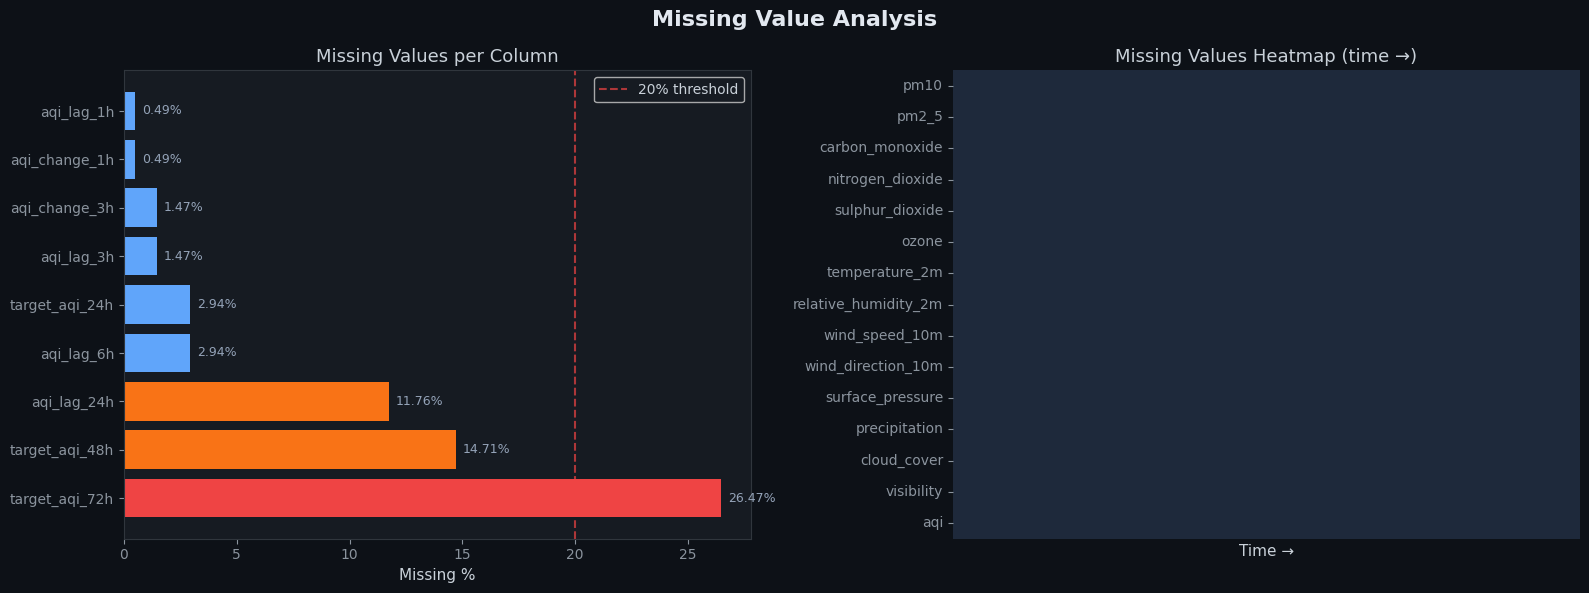


Total missing cells : 512
Complete rows       : 816 / 816


In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
miss_df = miss_df[miss_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Missing Value Analysis', fontsize=16, color='#e2e8f0', fontweight='bold')

# Bar chart
if not miss_df.empty:
    colors = ['#ef4444' if p > 20 else '#f97316' if p > 10 else '#60a5fa'
              for p in miss_df['Missing %']]
    axes[0].barh(miss_df.index, miss_df['Missing %'], color=colors)
    axes[0].set_xlabel('Missing %')
    axes[0].set_title('Missing Values per Column')
    axes[0].axvline(x=20, color='#ef4444', linestyle='--', alpha=0.7, label='20% threshold')
    axes[0].legend()
    for i, (_, row) in enumerate(miss_df.iterrows()):
        axes[0].text(row['Missing %'] + 0.3, i, f"{row['Missing %']}%",
                     va='center', fontsize=9, color='#94a3b8')
else:
    axes[0].text(0.5, 0.5, '✅ No Missing Values!', transform=axes[0].transAxes,
                 ha='center', va='center', fontsize=16, color='#4ade80')
    axes[0].set_title('Missing Values per Column')

# Heatmap of missing values over time
num_cols = [c for c in key_cols if c in df.columns]
miss_matrix = df[num_cols].isnull().astype(int)
# Downsample for viz
step = max(1, len(miss_matrix) // 100)
miss_sample = miss_matrix.iloc[::step]
sns.heatmap(miss_sample.T, cmap=['#1e293b','#ef4444'], ax=axes[1],
            cbar=False, yticklabels=True, xticklabels=False)
axes[1].set_title('Missing Values Heatmap (time →)')
axes[1].set_xlabel('Time →')

plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTotal missing cells : {df.isnull().sum().sum()}')
print(f'Complete rows       : {df.dropna(subset=key_cols).shape[0]} / {len(df)}')

---
## 4. Target Variable Analysis (AQI) <a id='4'></a>

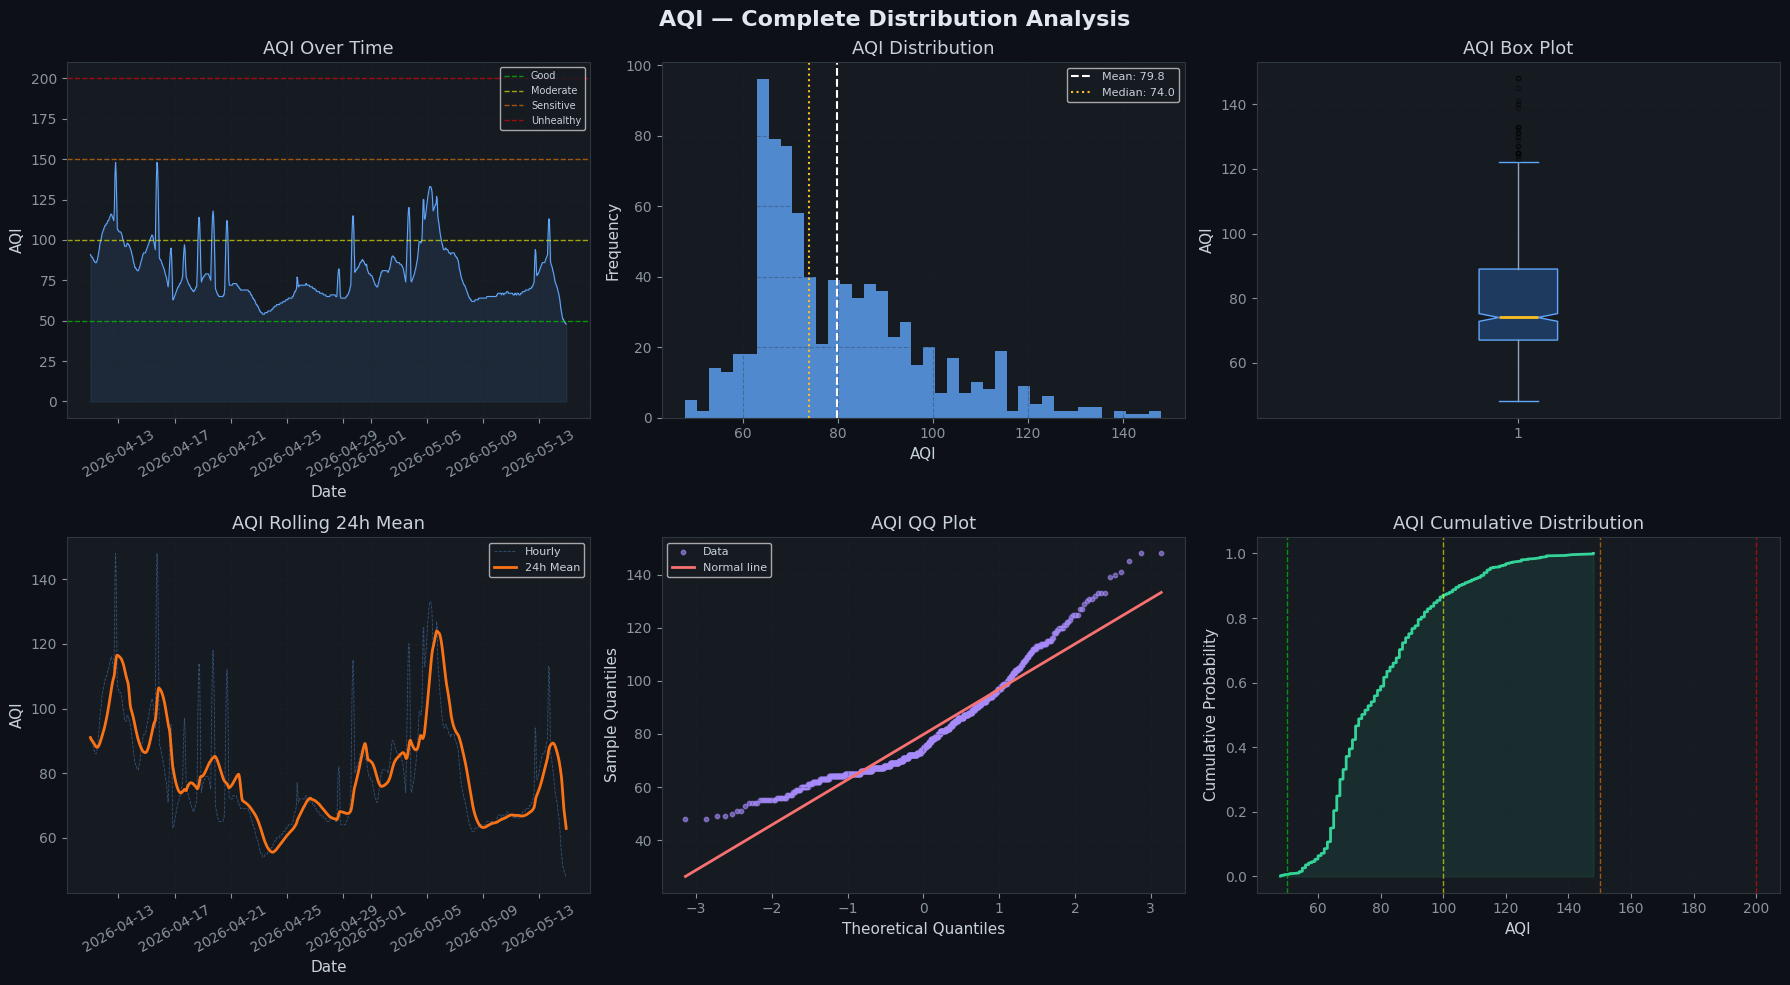


📊 AQI Statistics:
  Mean    : 79.82
  Median  : 74.00
  Std     : 17.74
  Min/Max : 48 / 148
  Skewness: 1.074
  Kurtosis: 0.947

  Shapiro-Wilk normality test:
  W=0.9152, p=0.000000
  → AQI is NOT normally distributed


In [ ]:
aqi = df['aqi'].dropna()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('AQI — Complete Distribution Analysis', fontsize=16, 
             color='#e2e8f0', fontweight='bold')
fig.patch.set_facecolor('#0d1117')

# 1. Time series
ax = axes[0, 0]
ax.plot(df['timestamp'], df['aqi'], color='#60a5fa', linewidth=0.8)
ax.fill_between(df['timestamp'], df['aqi'], alpha=0.1, color='#60a5fa')
for val, color, label in [(50,'#00e400','Good'),(100,'#ffff00','Moderate'),
                           (150,'#ff7e00','Sensitive'),(200,'#ff0000','Unhealthy')]:
    ax.axhline(y=val, linestyle='--', color=color, alpha=0.6, linewidth=1, label=label)
ax.set_title('AQI Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('AQI')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# 2. Histogram
ax = axes[0, 1]
ax.hist(aqi, bins=40, color='#60a5fa', alpha=0.8, edgecolor='none')
ax.axvline(aqi.mean(),   color='white',   linestyle='--', linewidth=1.5, label=f'Mean: {aqi.mean():.1f}')
ax.axvline(aqi.median(), color='#fbbf24', linestyle=':',  linewidth=1.5, label=f'Median: {aqi.median():.1f}')
ax.set_title('AQI Distribution')
ax.set_xlabel('AQI')
ax.set_ylabel('Frequency')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 3. Box plot
ax = axes[0, 2]
bp = ax.boxplot(aqi, patch_artist=True, notch=True,
                boxprops=dict(facecolor='#1e3a5f', color='#60a5fa'),
                medianprops=dict(color='#fbbf24', linewidth=2),
                whiskerprops=dict(color='#94a3b8'),
                capprops=dict(color='#60a5fa'),
                flierprops=dict(marker='o', color='#ef4444', alpha=0.4, markersize=3))
ax.set_title('AQI Box Plot')
ax.set_ylabel('AQI')
ax.grid(True, alpha=0.3, axis='y')

# 4. Rolling mean
ax = axes[1, 0]
rolling = df['aqi'].rolling(24, min_periods=1).mean()
ax.plot(df['timestamp'], df['aqi'], color='#60a5fa', linewidth=0.6, 
        alpha=0.4, linestyle='--', label='Hourly')
ax.plot(df['timestamp'], rolling, color='#f97316', linewidth=2, label='24h Mean')
ax.set_title('AQI Rolling 24h Mean')
ax.set_xlabel('Date')
ax.set_ylabel('AQI')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# 5. QQ Plot
ax = axes[1, 1]
qq = stats.probplot(aqi)
ax.scatter(qq[0][0], qq[0][1], color='#a78bfa', s=10, alpha=0.6, label='Data')
qq_line_y = qq[1][1] + qq[1][0] * np.array(qq[0][0])
ax.plot(qq[0][0], qq_line_y, color='#f87171', linewidth=2, label='Normal line')
ax.set_title('AQI QQ Plot')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 6. CDF
ax = axes[1, 2]
sorted_aqi = np.sort(aqi)
cdf = np.arange(1, len(sorted_aqi) + 1) / len(sorted_aqi)
ax.plot(sorted_aqi, cdf, color='#34d399', linewidth=2)
ax.fill_between(sorted_aqi, cdf, alpha=0.1, color='#34d399')
for val, color, label in [(50,'#00e400','Good'),(100,'#ffff00','Moderate'),
                           (150,'#ff7e00','Sensitive'),(200,'#ff0000','Unhealthy')]:
    ax.axvline(x=val, linestyle='--', color=color, alpha=0.6, linewidth=1)
ax.set_title('AQI Cumulative Distribution')
ax.set_xlabel('AQI')
ax.set_ylabel('Cumulative Probability')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('aqi_distribution.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()

print(f'\n📊 AQI Statistics:')
print(f'  Mean    : {aqi.mean():.2f}')
print(f'  Median  : {aqi.median():.2f}')
print(f'  Std     : {aqi.std():.2f}')
print(f'  Min/Max : {aqi.min():.0f} / {aqi.max():.0f}')
print(f'  Skewness: {aqi.skew():.3f}')
print(f'  Kurtosis: {aqi.kurtosis():.3f}')

stat, p = stats.shapiro(aqi.sample(min(500, len(aqi)), random_state=42))
print(f'\n  Shapiro-Wilk normality test:')
print(f'  W={stat:.4f}, p={p:.6f}')
print(f'  → AQI is {"NOT " if p < 0.05 else ""}normally distributed')

---
## 5. Pollutant Analysis <a id='5'></a>

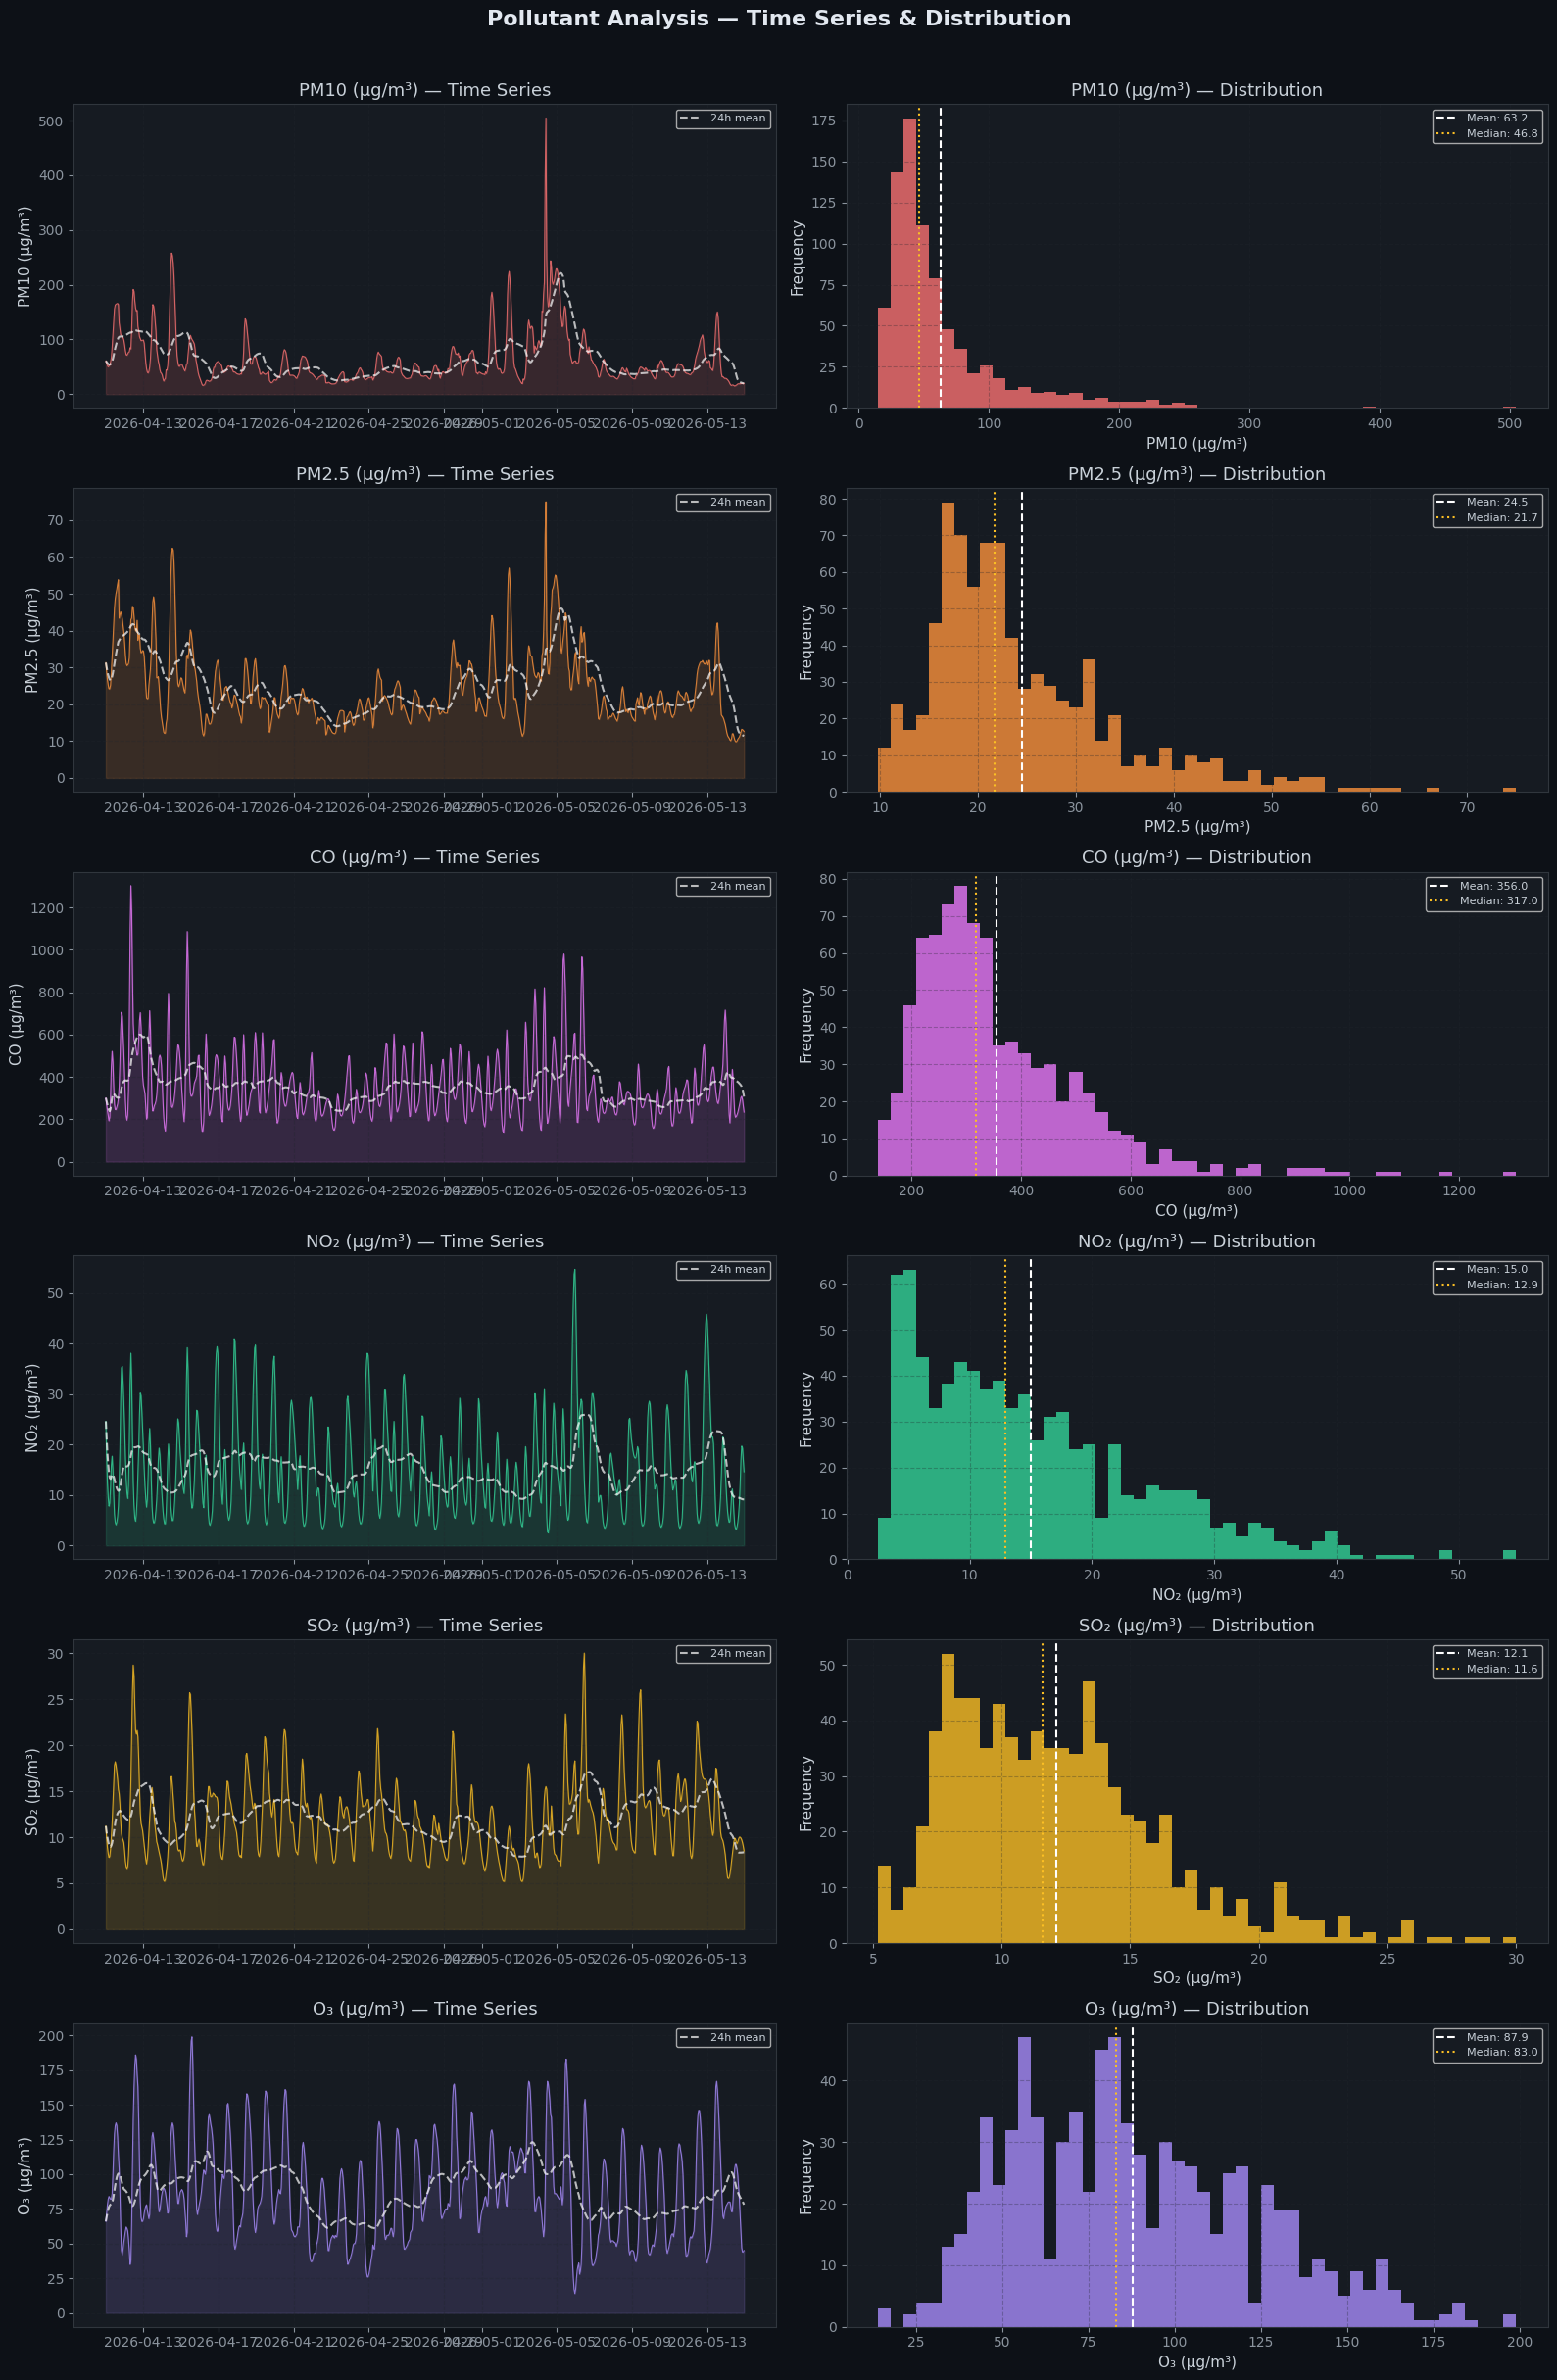


📊 Pollutant Statistics:


,count,mean,std,min,25%,50%,75%,max
PM10 (µg/m³),816.0,63.156,48.680,14.9,34.425,46.75,72.525,504.8
PM2.5 (µg/m³),816.0,24.496,9.703,9.8,17.900,21.70,29.000,75.0
CO (µg/m³),816.0,356.010,151.814,139.0,250.750,317.00,426.000,1304.0
NO₂ (µg/m³),816.0,15.002,9.349,2.5,7.600,12.90,20.100,54.7
SO₂ (µg/m³),816.0,12.132,4.176,5.2,8.800,11.60,14.400,30.0
O₃ (µg/m³),816.0,87.946,34.954,14.0,59.000,83.00,112.000,199.0


In [ ]:
poll_cols = [c for c in POLLUTANTS if c in df.columns]
poll_labels = {
    'pm10':             'PM10 (µg/m³)',
    'pm2_5':            'PM2.5 (µg/m³)',
    'carbon_monoxide':  'CO (µg/m³)',
    'nitrogen_dioxide': 'NO₂ (µg/m³)',
    'sulphur_dioxide':  'SO₂ (µg/m³)',
    'ozone':            'O₃ (µg/m³)',
}
poll_colors = ['#f87171','#fb923c','#e879f9','#34d399','#fbbf24','#a78bfa']

n = len(poll_cols)
fig, axes = plt.subplots(n, 2, figsize=(16, 4*n))
fig.suptitle('Pollutant Analysis — Time Series & Distribution', fontsize=16,
             color='#e2e8f0', fontweight='bold', y=1.01)

for i, (col, color) in enumerate(zip(poll_cols, poll_colors)):
    label = poll_labels.get(col, col)
    data  = df[col].dropna()

    # Time series
    axes[i,0].plot(df['timestamp'], df[col], color=color, linewidth=0.8, alpha=0.8)
    axes[i,0].fill_between(df['timestamp'], df[col], alpha=0.15, color=color)
    # Rolling mean
    roll = df[col].rolling(24, min_periods=1).mean()
    axes[i,0].plot(df['timestamp'], roll, color='white', linewidth=1.5,
                   linestyle='--', alpha=0.7, label='24h mean')
    axes[i,0].set_ylabel(label)
    axes[i,0].set_title(f'{label} — Time Series')
    axes[i,0].legend(fontsize=8)
    axes[i,0].grid(True, alpha=0.3)

    # Distribution
    axes[i,1].hist(data, bins=50, color=color, alpha=0.8, edgecolor='none')
    axes[i,1].axvline(data.mean(),   color='white',    linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.1f}')
    axes[i,1].axvline(data.median(), color='#fbbf24', linestyle=':',  linewidth=1.5, label=f'Median: {data.median():.1f}')
    axes[i,1].set_xlabel(label)
    axes[i,1].set_ylabel('Frequency')
    axes[i,1].set_title(f'{label} — Distribution')
    axes[i,1].legend(fontsize=8)
    axes[i,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pollutant_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Pollutant statistics table
print('\n📊 Pollutant Statistics:')
poll_stats = df[poll_cols].describe().T
poll_stats.index = [poll_labels.get(c, c) for c in poll_stats.index]
display(poll_stats.round(3))

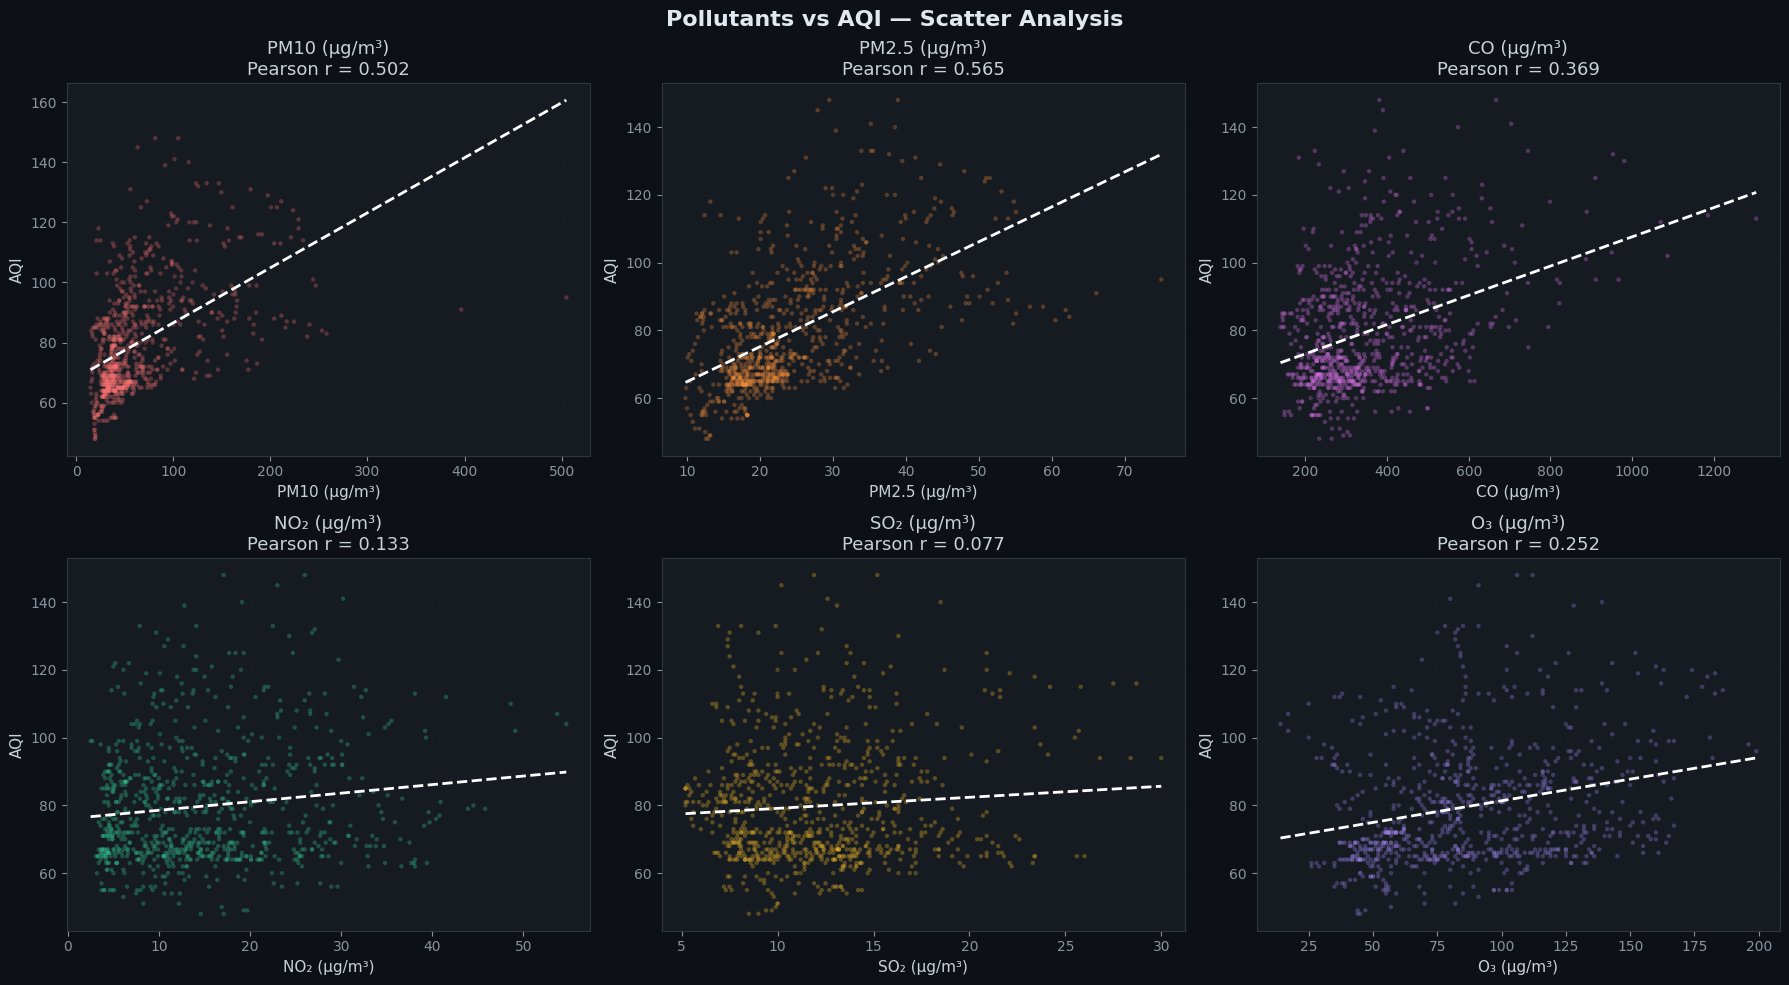

In [ ]:
# Pollutant vs AQI scatter plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Pollutants vs AQI — Scatter Analysis', fontsize=16,
             color='#e2e8f0', fontweight='bold')
axes = axes.flatten()

for i, (col, color) in enumerate(zip(poll_cols, poll_colors)):
    if i >= len(axes): break
    label = poll_labels.get(col, col)
    valid = df[[col, 'aqi']].dropna()

    axes[i].scatter(valid[col], valid['aqi'], alpha=0.3, color=color,
                    s=10, edgecolors='none')

    # Regression line
    if len(valid) > 5:
        z = np.polyfit(valid[col], valid['aqi'], 1)
        p = np.poly1d(z)
        xs = np.linspace(valid[col].min(), valid[col].max(), 100)
        axes[i].plot(xs, p(xs), color='white', linewidth=2, linestyle='--')
        corr = valid[col].corr(valid['aqi'])
        axes[i].set_title(f'{label}\nPearson r = {corr:.3f}')
    else:
        axes[i].set_title(label)

    axes[i].set_xlabel(label)
    axes[i].set_ylabel('AQI')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pollutants_vs_aqi.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Weather Feature Analysis <a id='6'></a>

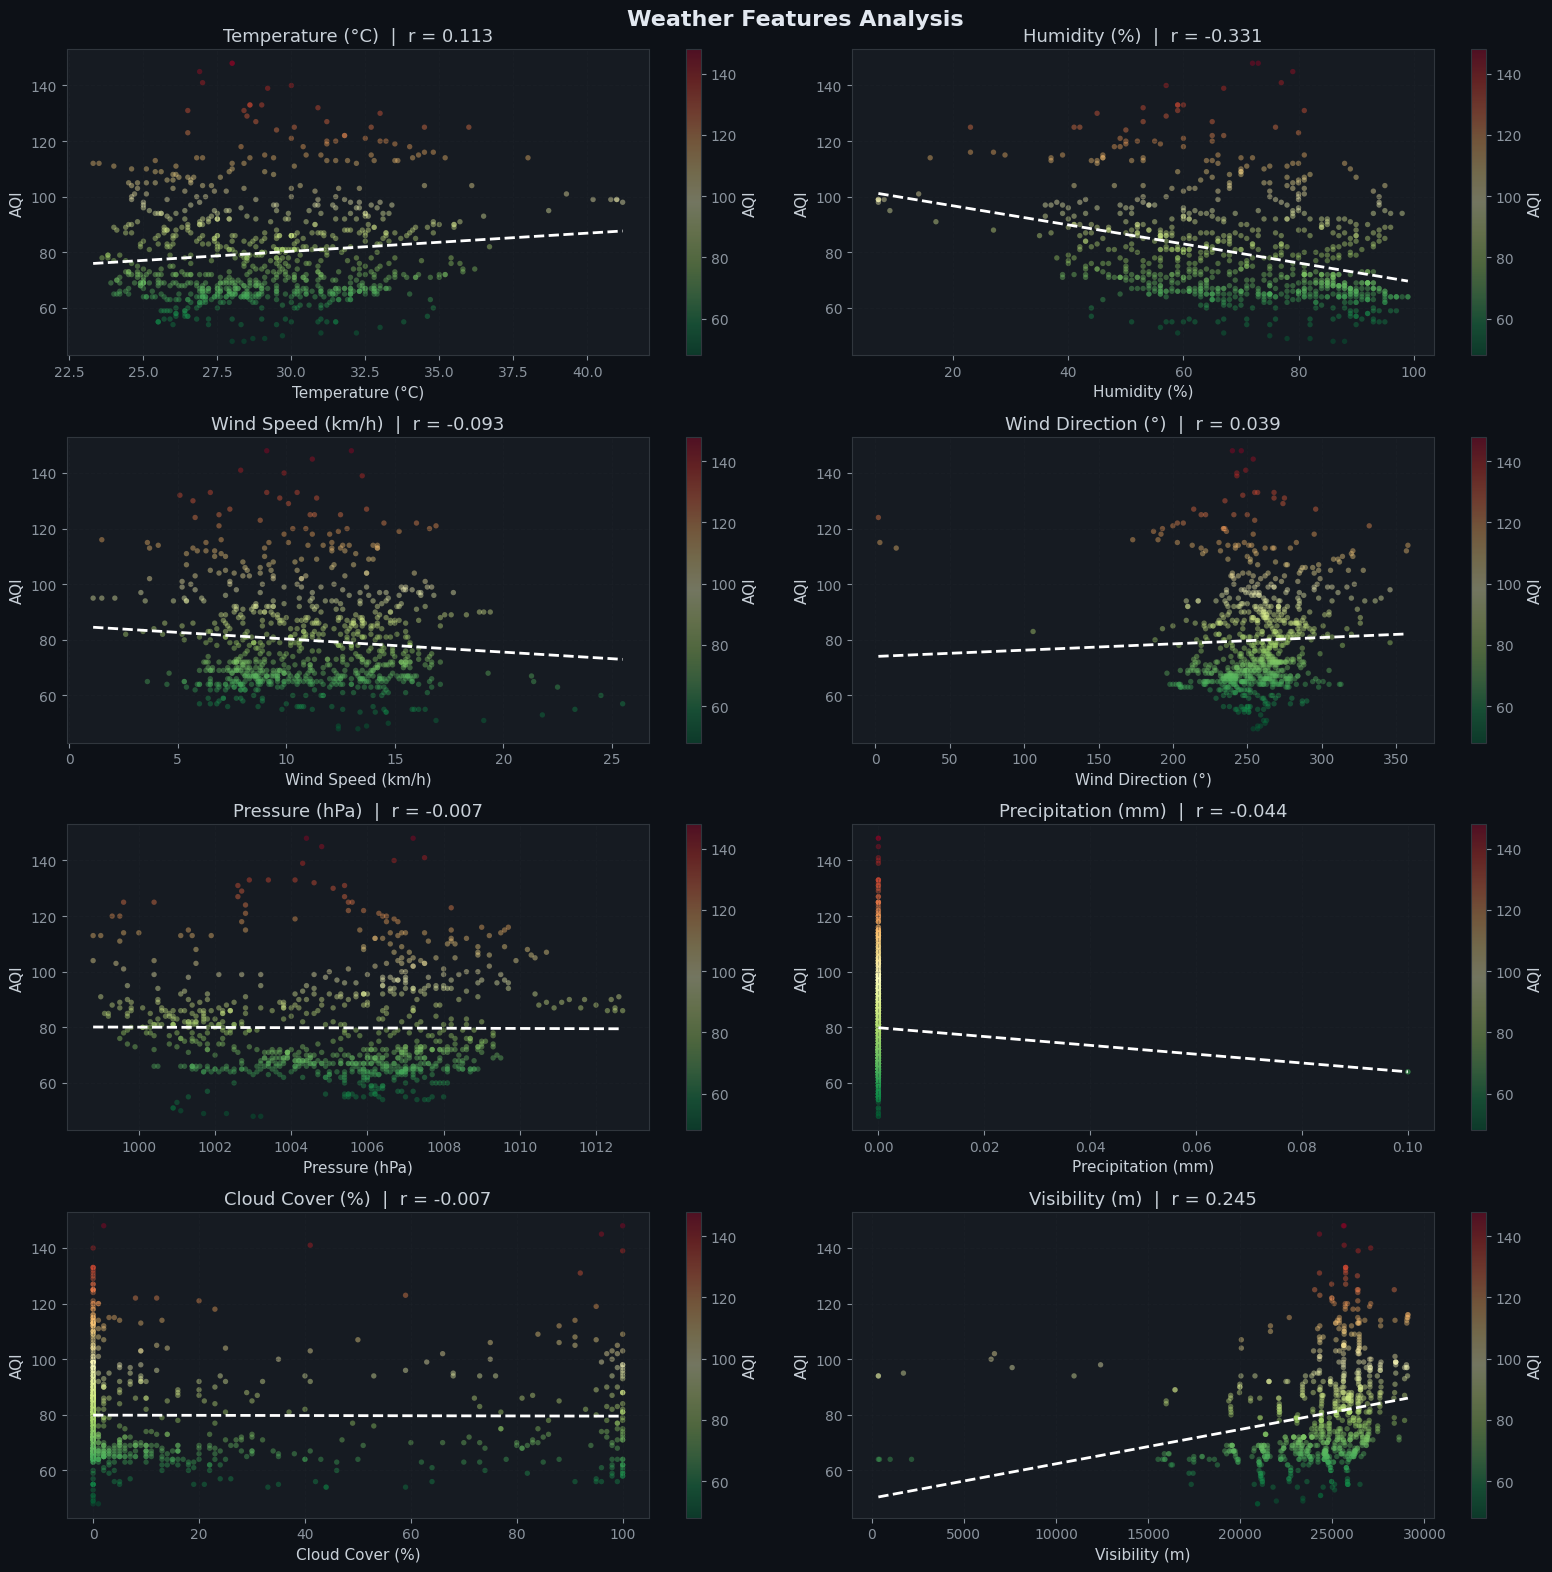

In [ ]:
wx_cols = [c for c in WEATHER if c in df.columns]
wx_labels = {
    'temperature_2m':       'Temperature (°C)',
    'relative_humidity_2m': 'Humidity (%)',
    'wind_speed_10m':       'Wind Speed (km/h)',
    'wind_direction_10m':   'Wind Direction (°)',
    'surface_pressure':     'Pressure (hPa)',
    'precipitation':        'Precipitation (mm)',
    'cloud_cover':          'Cloud Cover (%)',
    'visibility':           'Visibility (m)',
}
wx_colors = ['#f472b6','#38bdf8','#4ade80','#facc15','#c084fc','#67e8f9','#86efac','#fda4af']

n = len(wx_cols)
cols_per_row = 2
n_rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(16, 4*n_rows))
fig.suptitle('Weather Features Analysis', fontsize=16, color='#e2e8f0', fontweight='bold')
axes = axes.flatten() if n_rows > 1 else [axes] if n == 1 else axes.flatten()

for i, (col, color) in enumerate(zip(wx_cols, wx_colors)):
    label = wx_labels.get(col, col)
    data  = df[[col, 'aqi']].dropna()

    sc = axes[i].scatter(data[col], data['aqi'], c=data['aqi'],
                          cmap='RdYlGn_r', alpha=0.4, s=15, edgecolors='none')
    plt.colorbar(sc, ax=axes[i], label='AQI')

    if len(data) > 5:
        z = np.polyfit(data[col], data['aqi'], 1)
        p = np.poly1d(z)
        xs = np.linspace(data[col].min(), data[col].max(), 100)
        axes[i].plot(xs, p(xs), color='white', linewidth=2, linestyle='--')
        corr = data[col].corr(data['aqi'])
        axes[i].set_title(f'{label}  |  r = {corr:.3f}')
    else:
        axes[i].set_title(label)

    axes[i].set_xlabel(label)
    axes[i].set_ylabel('AQI')
    axes[i].grid(True, alpha=0.3)

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('weather_vs_aqi.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Wind Rose — wind direction vs AQI
if 'wind_direction_10m' in df.columns and 'wind_speed_10m' in df.columns:
    fig = go.Figure()
    aqi_bins = [(0,50,'Good','#00e400'), (51,100,'Moderate','#ffff00'),
                (101,150,'USG','#ff7e00'), (151,200,'Unhealthy','#ff0000'),
                (201,500,'Very+','#8f3f97')]

    for lo, hi, label, color in aqi_bins:
        mask = df['aqi'].between(lo, hi)
        sub  = df[mask].dropna(subset=['wind_direction_10m','wind_speed_10m'])
        if len(sub) == 0: continue
        fig.add_trace(go.Barpolar(
            r=sub['wind_speed_10m'],
            theta=sub['wind_direction_10m'],
            name=label,
            marker_color=color,
            opacity=0.7
        ))

    fig.update_layout(
        title='Wind Rose — Wind Speed & Direction colored by AQI Category',
        title_font_color='#e2e8f0',
        paper_bgcolor='#0d1117', plot_bgcolor='#161b22',
        font_color='#94a3b8',
        polar=dict(
            bgcolor='#161b22',
            angularaxis=dict(direction='clockwise', rotation=90,
                             tickcolor='#94a3b8', linecolor='#30363d'),
            radialaxis=dict(tickcolor='#94a3b8', linecolor='#30363d')
        ),
        height=500
    )
    fig.show()

---
## 7. Time-Based Trend Analysis <a id='7'></a>

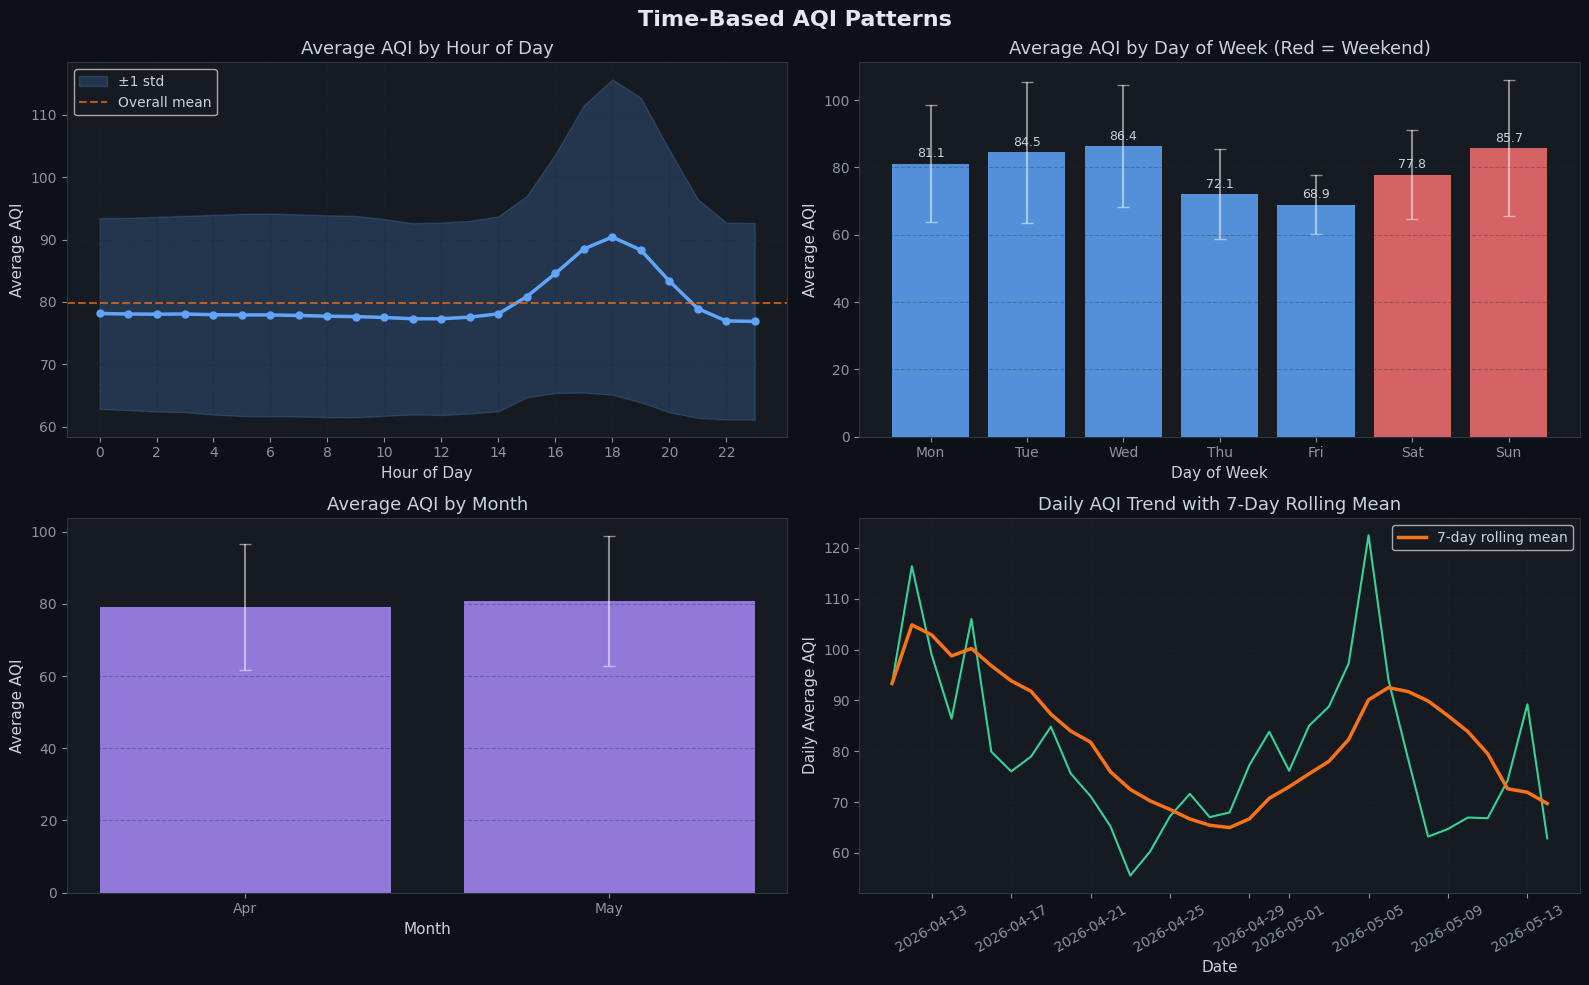

In [ ]:
# Hourly, daily, monthly AQI patterns
df['hour']        = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month']       = df['timestamp'].dt.month
df['date']        = df['timestamp'].dt.date

hour_avg  = df.groupby('hour')['aqi'].agg(['mean','std','median']).reset_index()
dow_avg   = df.groupby('day_of_week')['aqi'].agg(['mean','std']).reset_index()
month_avg = df.groupby('month')['aqi'].agg(['mean','std']).reset_index()
daily_avg = df.groupby('date')['aqi'].mean().reset_index()

days_map   = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
months_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
              7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Time-Based AQI Patterns', fontsize=16, color='#e2e8f0', fontweight='bold')

# Hourly
ax = axes[0,0]
ax.plot(hour_avg['hour'], hour_avg['mean'], color='#60a5fa', linewidth=2.5, marker='o', markersize=5)
ax.fill_between(hour_avg['hour'],
    hour_avg['mean'] - hour_avg['std'],
    hour_avg['mean'] + hour_avg['std'],
    alpha=0.2, color='#60a5fa', label='±1 std')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average AQI')
ax.set_title('Average AQI by Hour of Day')
ax.set_xticks(range(0,24,2))
ax.axhline(y=hour_avg['mean'].mean(), color='#f97316', linestyle='--', alpha=0.7, label='Overall mean')
ax.legend()
ax.grid(True, alpha=0.3)

# Day of week
ax = axes[0,1]
colors_dow = ['#f87171' if d >= 5 else '#60a5fa' for d in dow_avg['day_of_week']]
bars = ax.bar([days_map[d] for d in dow_avg['day_of_week']],
              dow_avg['mean'], color=colors_dow, alpha=0.85)
ax.errorbar([days_map[d] for d in dow_avg['day_of_week']],
            dow_avg['mean'], yerr=dow_avg['std'],
            fmt='none', color='white', capsize=4, alpha=0.5)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average AQI')
ax.set_title('Average AQI by Day of Week (Red = Weekend)')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Monthly
ax = axes[1,0]
months_present = [months_map[m] for m in month_avg['month']]
ax.bar(months_present, month_avg['mean'], color='#a78bfa', alpha=0.85)
ax.errorbar(months_present, month_avg['mean'], yerr=month_avg['std'],
            fmt='none', color='white', capsize=4, alpha=0.5)
ax.set_xlabel('Month')
ax.set_ylabel('Average AQI')
ax.set_title('Average AQI by Month')
ax.grid(True, alpha=0.3, axis='y')

# Daily trend
ax = axes[1,1]
daily_avg['date'] = pd.to_datetime(daily_avg['date'])
ax.plot(daily_avg['date'], daily_avg['aqi'], color='#34d399', linewidth=1.5)
# 7-day rolling
roll7 = daily_avg['aqi'].rolling(7, min_periods=1).mean()
ax.plot(daily_avg['date'], roll7, color='#f97316', linewidth=2.5,
        label='7-day rolling mean')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Average AQI')
ax.set_title('Daily AQI Trend with 7-Day Rolling Mean')
ax.legend()
ax.grid(True, alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('time_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

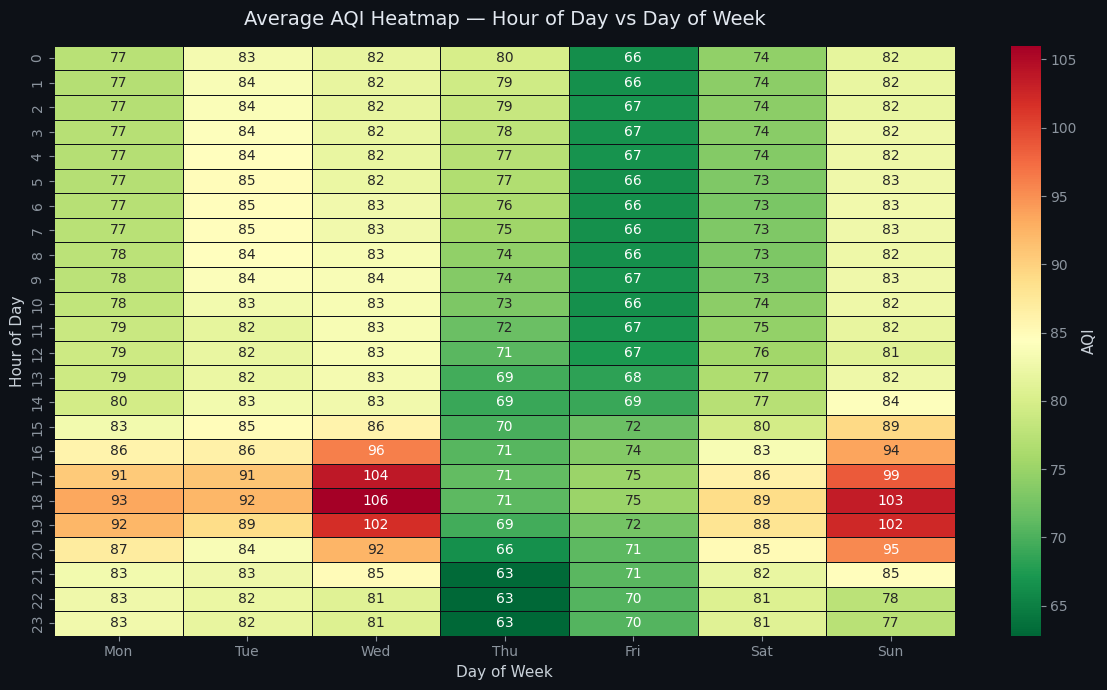


💡 Key Insight: Identify peak pollution hours and days from heatmap


In [ ]:
# Heatmap: Hour vs Day of Week
if len(df) > 100:
    pivot = df.pivot_table(values='aqi', index='hour', columns='day_of_week', aggfunc='mean')
    pivot.columns = [days_map[c] for c in pivot.columns]

    fig, ax = plt.subplots(figsize=(12, 7))
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn_r',
                linewidths=0.5, linecolor='#0d1117',
                ax=ax, cbar_kws={'label': 'AQI'})
    ax.set_title('Average AQI Heatmap — Hour of Day vs Day of Week',
                 fontsize=14, color='#e2e8f0', pad=15)
    ax.set_xlabel('Day of Week')
    ax.set_ylabel('Hour of Day')
    plt.tight_layout()
    plt.savefig('heatmap_hour_dow.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n💡 Key Insight: Identify peak pollution hours and days from heatmap')

---
## 8. Correlation Analysis <a id='8'></a>

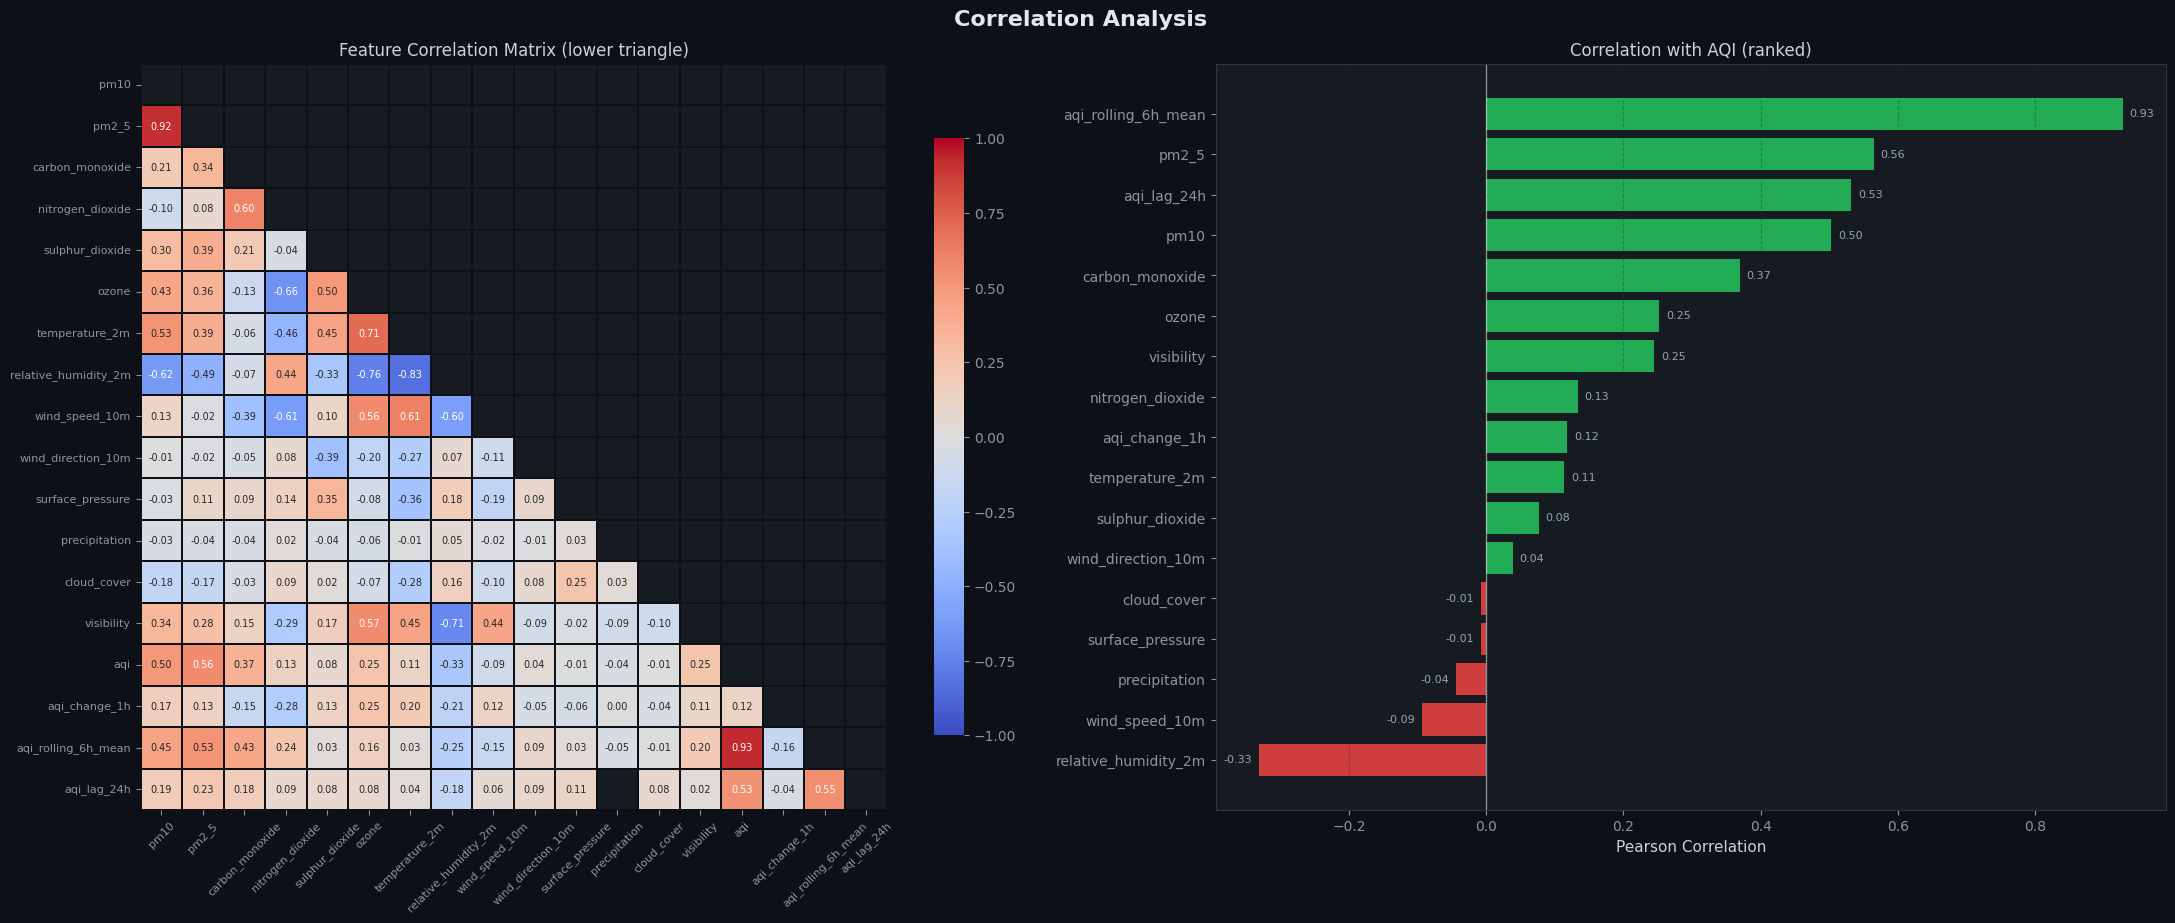


🔗 Top 10 Features Correlated with AQI:
  +0.927  aqi_rolling_6h_mean
  +0.565  pm2_5
  +0.532  aqi_lag_24h
  +0.502  pm10
  +0.369  carbon_monoxide
  -0.331  relative_humidity_2m
  +0.252  ozone
  +0.245  visibility
  +0.133  nitrogen_dioxide
  +0.118  aqi_change_1h


In [ ]:
# Full correlation matrix
corr_cols = [c for c in (POLLUTANTS + WEATHER + ['aqi','aqi_change_1h',
              'aqi_rolling_6h_mean','aqi_lag_24h']) if c in df.columns]
corr_df = df[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle('Correlation Analysis', fontsize=16, color='#e2e8f0', fontweight='bold')

# Full heatmap
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, linecolor='#0d1117',
            ax=axes[0], annot_kws={'size': 7},
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Feature Correlation Matrix (lower triangle)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

# AQI correlations ranked
if 'aqi' in corr_df.columns:
    aqi_corr = corr_df['aqi'].drop('aqi').sort_values()
    colors_bar = ['#ef4444' if v < 0 else '#22c55e' for v in aqi_corr]
    axes[1].barh(aqi_corr.index, aqi_corr.values, color=colors_bar, alpha=0.85)
    axes[1].axvline(x=0, color='white', linewidth=1, alpha=0.5)
    axes[1].set_title('Correlation with AQI (ranked)', fontsize=12)
    axes[1].set_xlabel('Pearson Correlation')
    axes[1].grid(True, alpha=0.3, axis='x')
    for i, (name, val) in enumerate(aqi_corr.items()):
        axes[1].text(val + (0.01 if val >= 0 else -0.01), i,
                     f'{val:.2f}', va='center', fontsize=8,
                     ha='left' if val >= 0 else 'right', color='#94a3b8')

plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with AQI
if 'aqi' in corr_df.columns:
    top_corr = corr_df['aqi'].drop('aqi').abs().sort_values(ascending=False).head(10)
    print('\n🔗 Top 10 Features Correlated with AQI:')
    for feat, val in top_corr.items():
        direction = '+' if corr_df.loc[feat,'aqi'] > 0 else '-'
        print(f'  {direction}{val:.3f}  {feat}')

---
## 9. Feature Distribution Analysis <a id='9'></a>

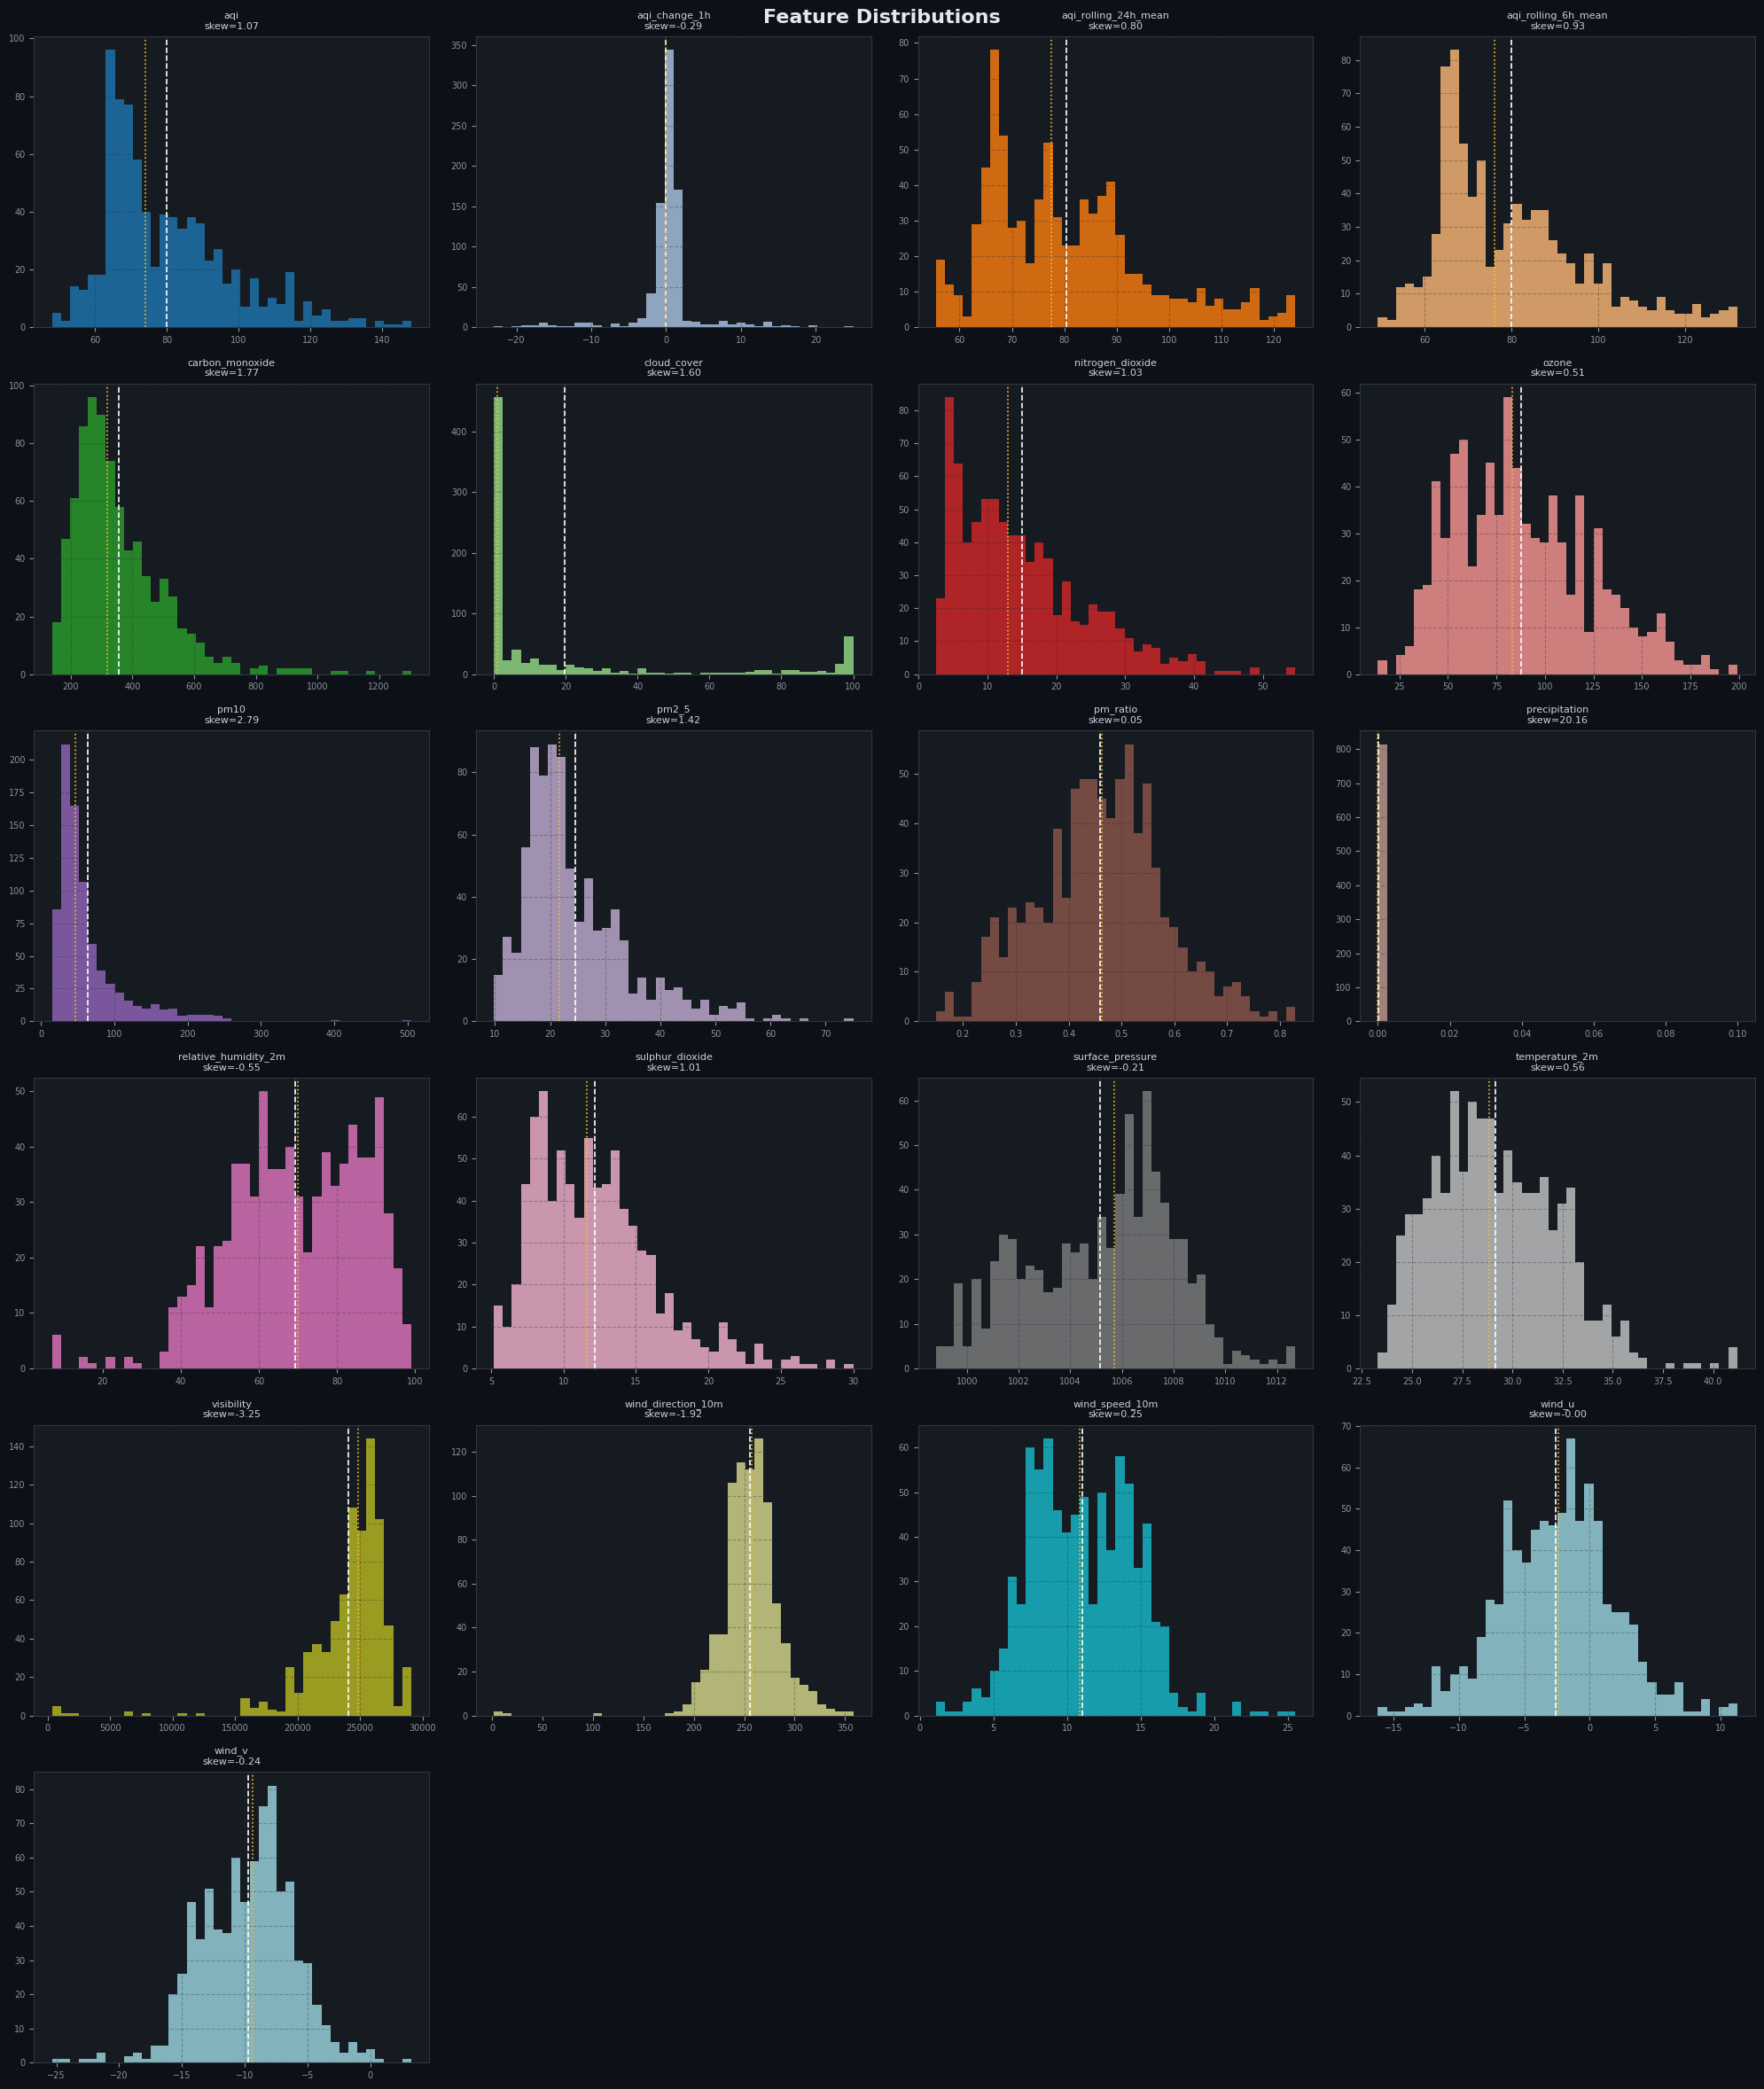

In [ ]:
# All numeric features distributions
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude  = ['latitude','longitude','hour','day_of_week','month','day_of_year',
             'is_weekend','hour_sin','hour_cos','month_sin','month_cos']
plot_cols = [c for c in num_cols if c not in exclude and c in
             (POLLUTANTS + WEATHER + ['aqi','aqi_change_1h','aqi_rolling_6h_mean',
              'aqi_rolling_24h_mean','pm_ratio','wind_u','wind_v'])]
plot_cols = [c for c in plot_cols if c in df.columns]

n = len(plot_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4*nrows))
fig.suptitle('Feature Distributions', fontsize=16, color='#e2e8f0', fontweight='bold')
axes = axes.flatten()

cmap = plt.cm.get_cmap('tab20', n)
for i, col in enumerate(plot_cols):
    data = df[col].dropna()
    color = cmap(i)

    axes[i].hist(data, bins=40, color=color, alpha=0.8, edgecolor='none')
    axes[i].axvline(data.mean(),   color='white',   linestyle='--', linewidth=1.2)
    axes[i].axvline(data.median(), color='#fbbf24', linestyle=':',  linewidth=1.2)
    axes[i].set_title(f'{col}\nskew={data.skew():.2f}', fontsize=8)
    axes[i].tick_params(labelsize=7)
    axes[i].grid(True, alpha=0.3)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Outlier Detection <a id='10'></a>

📊 Outlier Summary:


,Feature,Q1,Q3,IQR Lower,IQR Upper,IQR Outliers,IQR Outliers %,Z-score Outliers
0,aqi,67.00,89.00,34.00,122.00,22,2.70,6
1,pm10,34.42,72.53,-22.73,129.68,76,9.31,19
2,pm2_5,17.90,29.00,1.25,45.65,35,4.29,14
3,carbon_monoxide,250.75,426.00,-12.12,688.88,27,3.31,15
4,nitrogen_dioxide,7.60,20.10,-11.15,38.85,17,2.08,7
5,sulphur_dioxide,8.80,14.40,0.40,22.80,18,2.21,10
6,ozone,59.00,112.00,-20.50,191.50,2,0.25,2
7,temperature_2m,26.90,31.40,20.15,38.15,7,0.86,7
8,wind_speed_10m,8.30,13.70,0.20,21.80,5,0.61,5


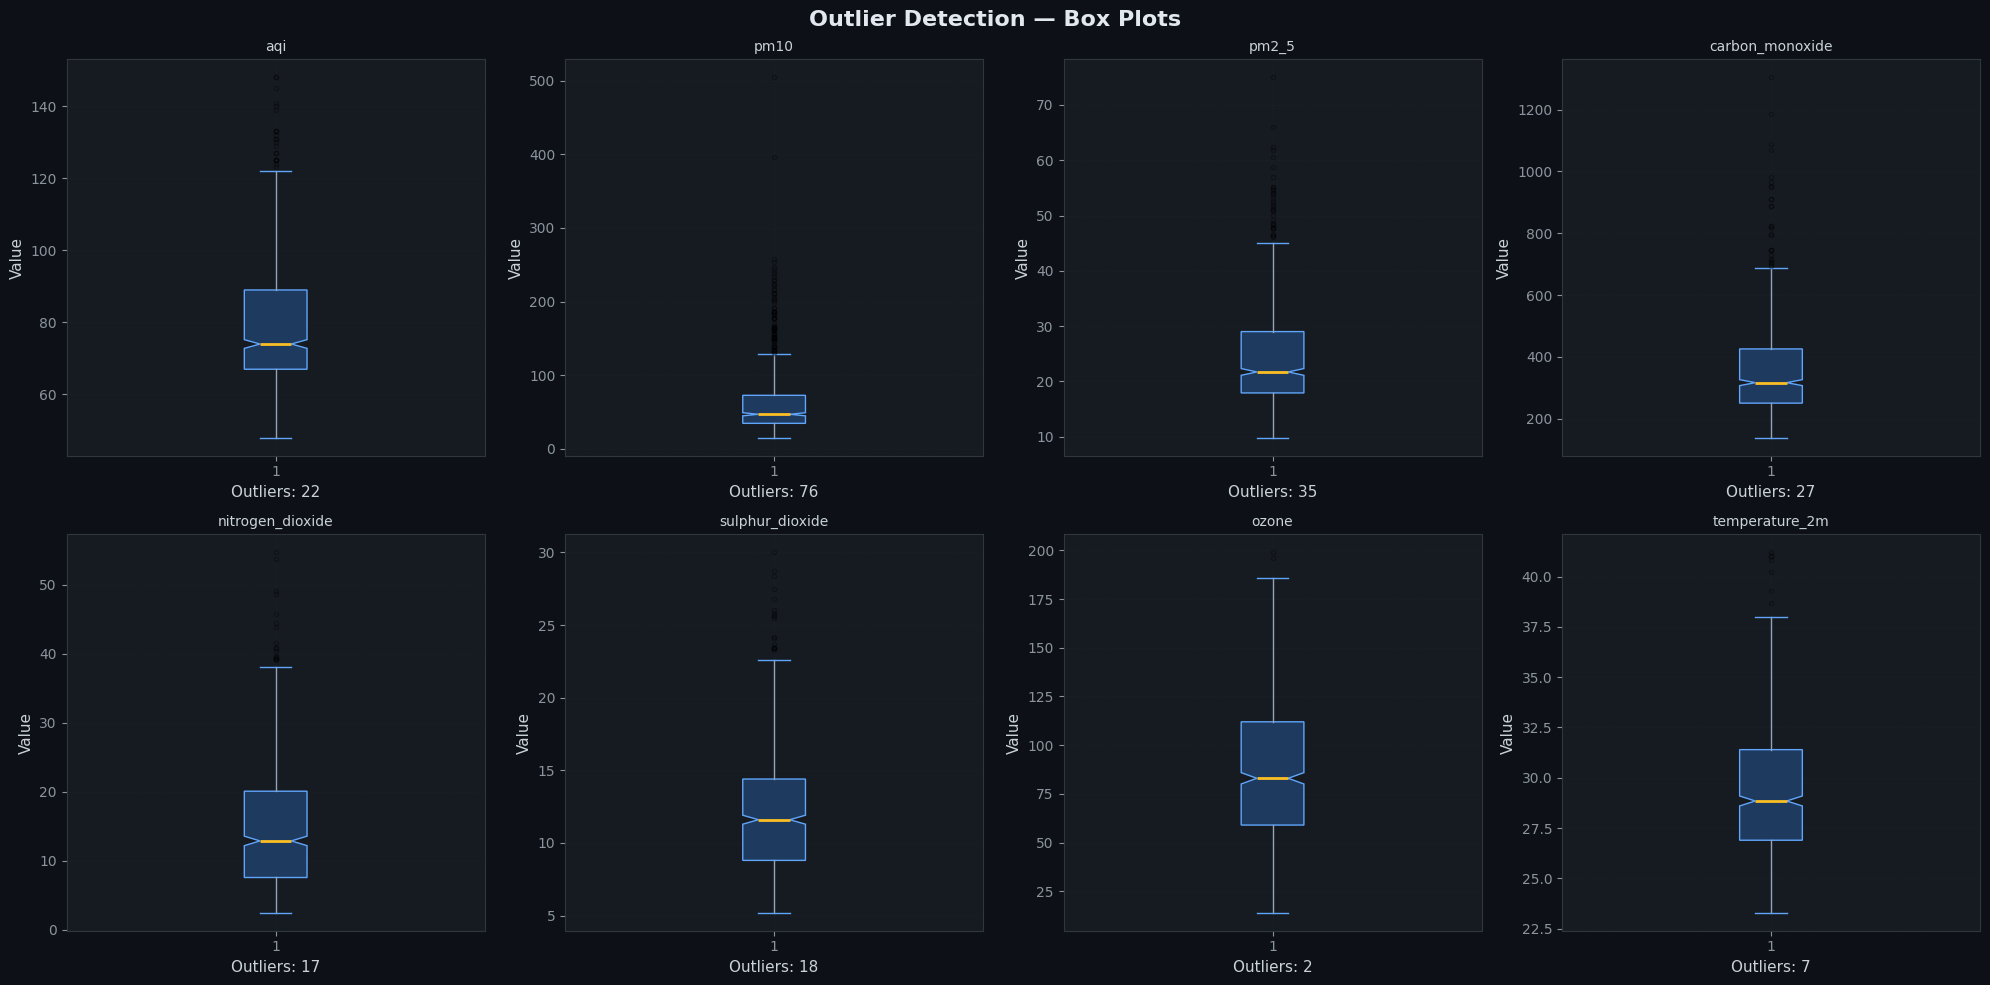

In [ ]:
# IQR-based outlier detection
check_cols = [c for c in (['aqi'] + POLLUTANTS + ['temperature_2m','wind_speed_10m'])
              if c in df.columns]

outlier_summary = []
for col in check_cols:
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR    = Q3 - Q1
    lower  = Q1 - 1.5 * IQR
    upper  = Q3 + 1.5 * IQR
    n_out  = ((data < lower) | (data > upper)).sum()
    z_out  = (np.abs(stats.zscore(data)) > 3).sum()
    outlier_summary.append({
        'Feature': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
        'IQR Lower': round(lower,2), 'IQR Upper': round(upper,2),
        'IQR Outliers': n_out, 'IQR Outliers %': round(n_out/len(data)*100,2),
        'Z-score Outliers': z_out
    })

out_df = pd.DataFrame(outlier_summary)
print('📊 Outlier Summary:')
display(out_df)

# Box plots
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Outlier Detection — Box Plots', fontsize=16, color='#e2e8f0', fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(check_cols[:8]):
    data = df[col].dropna()
    bp = axes[i].boxplot(data, patch_artist=True, notch=True,
                          boxprops=dict(facecolor='#1e3a5f', color='#60a5fa'),
                          medianprops=dict(color='#fbbf24', linewidth=2),
                          whiskerprops=dict(color='#94a3b8'),
                          capprops=dict(color='#60a5fa'),
                          flierprops=dict(marker='o', color='#ef4444', alpha=0.3, markersize=3))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Value')
    n_out = out_df[out_df['Feature']==col]['IQR Outliers'].values
    if len(n_out) > 0:
        axes[i].set_xlabel(f'Outliers: {n_out[0]}')
    axes[i].grid(True, alpha=0.3)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('outlier_detection.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. AQI Category Analysis <a id='11'></a>

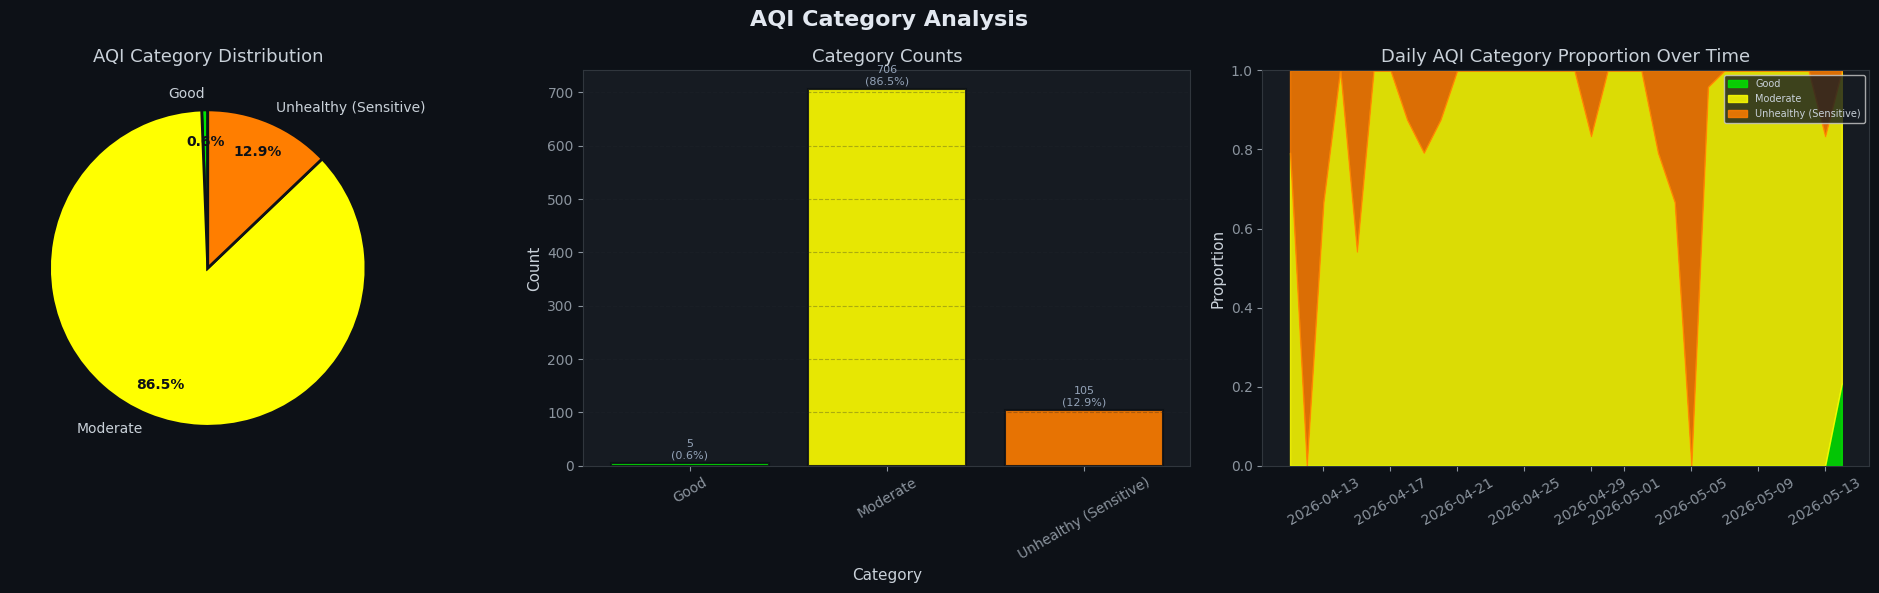


📊 AQI Category Summary:
  Good                          :     5 hours (  0.6%)
  Moderate                      :   706 hours ( 86.5%)
  Unhealthy (Sensitive)         :   105 hours ( 12.9%)


In [ ]:
# Add AQI category
def get_category(val):
    if pd.isna(val): return 'Unknown'
    if val <= 50:    return 'Good'
    if val <= 100:   return 'Moderate'
    if val <= 150:   return 'Unhealthy (Sensitive)'
    if val <= 200:   return 'Unhealthy'
    if val <= 300:   return 'Very Unhealthy'
    return 'Hazardous'

CAT_COLORS = {
    'Good':                 '#00e400',
    'Moderate':             '#ffff00',
    'Unhealthy (Sensitive)':'#ff7e00',
    'Unhealthy':            '#ff0000',
    'Very Unhealthy':       '#8f3f97',
    'Hazardous':            '#7e0023',
    'Unknown':              '#555555',
}
CAT_ORDER = ['Good','Moderate','Unhealthy (Sensitive)','Unhealthy','Very Unhealthy','Hazardous']

df['aqi_category'] = df['aqi'].apply(get_category)
cat_counts = df['aqi_category'].value_counts()
cat_pct    = (cat_counts / len(df) * 100).round(2)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('AQI Category Analysis', fontsize=16, color='#e2e8f0', fontweight='bold')

# Pie chart
cats     = [c for c in CAT_ORDER if c in cat_counts.index]
vals     = [cat_counts[c] for c in cats]
colors_p = [CAT_COLORS[c] for c in cats]
wedges, texts, autotexts = axes[0].pie(
    vals, labels=cats, colors=colors_p, autopct='%1.1f%%',
    startangle=90, pctdistance=0.8,
    wedgeprops=dict(edgecolor='#0d1117', linewidth=2)
)
for t in texts: t.set_color('#c9d1d9')
for t in autotexts: t.set_color('#0d1117'); t.set_fontweight('bold')
axes[0].set_title('AQI Category Distribution')

# Bar chart
bars = axes[1].bar(cats, vals, color=colors_p, alpha=0.9,
                    edgecolor='#0d1117', linewidth=1.5)
axes[1].set_title('Category Counts')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=8, color='#94a3b8')
axes[1].grid(True, alpha=0.3, axis='y')

# Category over time (stacked area)
if 'date' in df.columns:
    daily_cats = df.groupby(['date','aqi_category']).size().unstack(fill_value=0)
    daily_cats.index = pd.to_datetime(daily_cats.index)
    # Normalize
    daily_cats_pct = daily_cats.div(daily_cats.sum(axis=1), axis=0)
    plot_cats = [c for c in CAT_ORDER if c in daily_cats_pct.columns]
    bottom = np.zeros(len(daily_cats_pct))
    for cat in plot_cats:
        axes[2].fill_between(daily_cats_pct.index, bottom,
                              bottom + daily_cats_pct[cat].values,
                              color=CAT_COLORS[cat], alpha=0.85, label=cat)
        bottom += daily_cats_pct[cat].values
    axes[2].set_title('Daily AQI Category Proportion Over Time')
    axes[2].set_ylabel('Proportion')
    axes[2].set_ylim(0, 1)
    axes[2].legend(loc='upper right', fontsize=7)
    plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('aqi_categories.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 AQI Category Summary:')
for cat in CAT_ORDER:
    if cat in cat_counts:
        print(f'  {cat:30s}: {cat_counts[cat]:5d} hours ({cat_pct[cat]:5.1f}%)')

---
## 12. Lag & Rolling Feature Analysis <a id='12'></a>

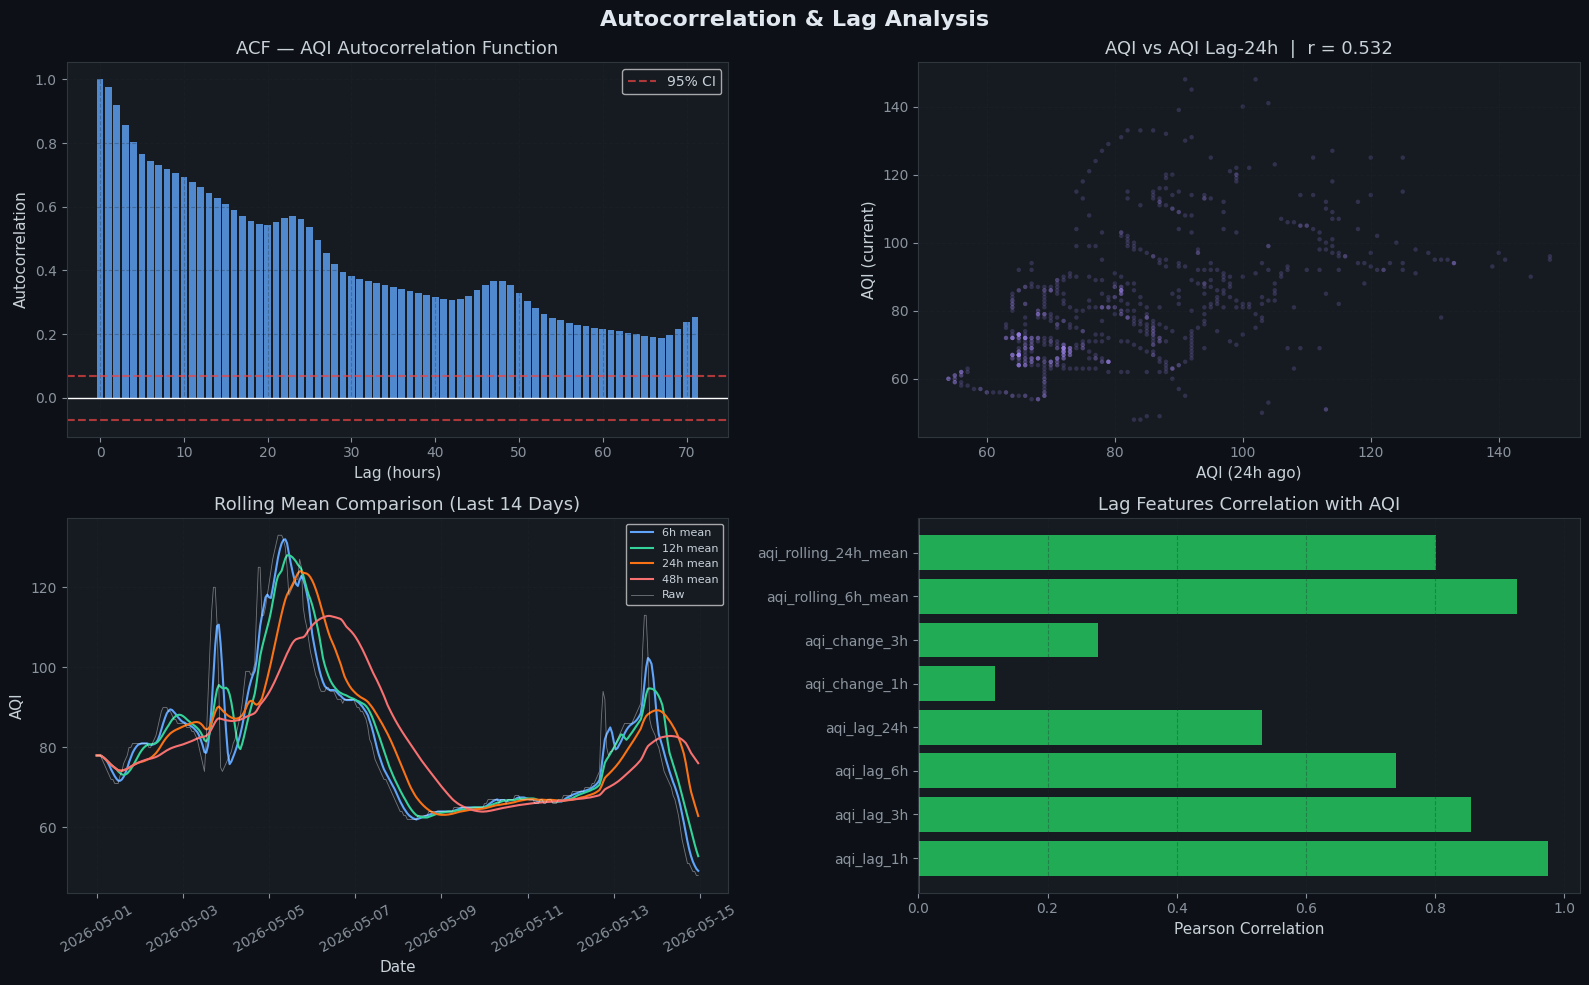

In [ ]:
# Autocorrelation analysis
from pandas.plotting import autocorrelation_plot

aqi_series = df['aqi'].dropna()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Autocorrelation & Lag Analysis', fontsize=16, color='#e2e8f0', fontweight='bold')

# ACF manual
max_lag = min(72, len(aqi_series)//4)
acf_vals = [aqi_series.autocorr(lag=i) for i in range(max_lag)]
axes[0,0].bar(range(max_lag), acf_vals, color='#60a5fa', alpha=0.8)
axes[0,0].axhline(y=0, color='white', linewidth=1)
conf = 1.96 / np.sqrt(len(aqi_series))
axes[0,0].axhline(y=conf,  color='#ef4444', linestyle='--', alpha=0.7, label='95% CI')
axes[0,0].axhline(y=-conf, color='#ef4444', linestyle='--', alpha=0.7)
axes[0,0].set_xlabel('Lag (hours)')
axes[0,0].set_ylabel('Autocorrelation')
axes[0,0].set_title('ACF — AQI Autocorrelation Function')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Lag scatter: AQI vs AQI 24h ago
lag_df = df[['aqi','aqi_lag_24h']].dropna()
axes[0,1].scatter(lag_df['aqi_lag_24h'], lag_df['aqi'],
                   alpha=0.2, color='#a78bfa', s=10, edgecolors='none')
corr_24 = lag_df['aqi'].corr(lag_df['aqi_lag_24h'])
axes[0,1].set_xlabel('AQI (24h ago)')
axes[0,1].set_ylabel('AQI (current)')
axes[0,1].set_title(f'AQI vs AQI Lag-24h  |  r = {corr_24:.3f}')
axes[0,1].grid(True, alpha=0.3)

# Rolling windows comparison
sample = df[['timestamp','aqi']].dropna().tail(24*14)  # last 14 days
for window, color, label in [(6,'#60a5fa','6h'), (12,'#34d399','12h'),
                               (24,'#f97316','24h'), (48,'#f87171','48h')]:
    roll = sample['aqi'].rolling(window, min_periods=1).mean()
    axes[1,0].plot(sample['timestamp'], roll, color=color, linewidth=1.5, label=f'{label} mean')
axes[1,0].plot(sample['timestamp'], sample['aqi'], color='white',
                linewidth=0.6, alpha=0.4, label='Raw')
axes[1,0].set_title('Rolling Mean Comparison (Last 14 Days)')
axes[1,0].set_xlabel('Date')
axes[1,0].set_ylabel('AQI')
axes[1,0].legend(fontsize=8)
axes[1,0].grid(True, alpha=0.3)
plt.setp(axes[1,0].xaxis.get_majorticklabels(), rotation=30)

# Lag feature correlation with target
lag_features = [c for c in ['aqi_lag_1h','aqi_lag_3h','aqi_lag_6h','aqi_lag_24h',
                              'aqi_change_1h','aqi_change_3h',
                              'aqi_rolling_6h_mean','aqi_rolling_24h_mean']
                if c in df.columns]
lag_corrs = [df[c].corr(df['aqi']) for c in lag_features]
colors_lag = ['#22c55e' if v > 0 else '#ef4444' for v in lag_corrs]
axes[1,1].barh(lag_features, lag_corrs, color=colors_lag, alpha=0.85)
axes[1,1].axvline(x=0, color='white', linewidth=1)
axes[1,1].set_title('Lag Features Correlation with AQI')
axes[1,1].set_xlabel('Pearson Correlation')
axes[1,1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('lag_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 13. Key Insights & Summary <a id='13'></a>

In [ ]:
# Final summary dashboard — Pie ke liye spec define karna zaroori hai
fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=[
        'AQI Full Time Series',
        'Top Pollutant Correlations with AQI',
        'Hourly AQI Pattern',
        'AQI Category Breakdown',
        'Temperature vs AQI',
        'PM2.5 vs PM10'
    ],
    specs=[
        [{"type": "xy"},     {"type": "xy"},     {"type": "xy"}],
        [{"type": "domain"}, {"type": "xy"},     {"type": "xy"}]
    ]
)

# 1. Full AQI time series
fig.add_trace(go.Scatter(x=df['timestamp'], y=df['aqi'],
    mode='lines', line=dict(color='#60a5fa', width=1),
    fill='tozeroy', fillcolor='rgba(96,165,250,0.1)',
    name='AQI'), row=1, col=1)

# 2. Pollutant correlations
if 'aqi' in df.columns:
    poll_corr = {c: df[c].corr(df['aqi']) for c in POLLUTANTS if c in df.columns}
    poll_corr = dict(sorted(poll_corr.items(), key=lambda x: abs(x[1]), reverse=True))
    fig.add_trace(go.Bar(
        x=list(poll_corr.keys()),
        y=list(poll_corr.values()),
        marker_color=['#22c55e' if v > 0 else '#ef4444' for v in poll_corr.values()],
        name='Correlation'
    ), row=1, col=2)

# 3. Hourly pattern
hourly = df.groupby('hour')['aqi'].mean().reset_index()
fig.add_trace(go.Scatter(x=hourly['hour'], y=hourly['aqi'],
    mode='lines+markers', line=dict(color='#f97316', width=2),
    marker=dict(size=6), name='Hourly Avg'), row=1, col=3)

# 4. AQI categories pie — type="domain" subplot mein jaata hai
fig.add_trace(go.Pie(
    labels=[c for c in CAT_ORDER if c in cat_counts],
    values=[cat_counts.get(c, 0) for c in CAT_ORDER if c in cat_counts],
    marker_colors=[CAT_COLORS[c] for c in CAT_ORDER if c in cat_counts],
    hole=0.4,
    name='Categories',
    textinfo='percent+label',
    textfont_size=9,
), row=2, col=1)

# 5. Temp vs AQI
if 'temperature_2m' in df.columns:
    temp_aqi = df[['temperature_2m', 'aqi']].dropna()
    fig.add_trace(go.Scatter(
        x=temp_aqi['temperature_2m'], y=temp_aqi['aqi'],
        mode='markers',
        marker=dict(color=temp_aqi['aqi'], colorscale='RdYlGn_r',
                    size=4, opacity=0.5),
        name='Temp vs AQI'
    ), row=2, col=2)

# 6. PM2.5 vs PM10
if 'pm2_5' in df.columns and 'pm10' in df.columns:
    pm = df[['pm2_5', 'pm10', 'aqi']].dropna()
    fig.add_trace(go.Scatter(
        x=pm['pm10'], y=pm['pm2_5'],
        mode='markers',
        marker=dict(color=pm['aqi'], colorscale='RdYlGn_r',
                    size=4, opacity=0.5),
        name='PM10 vs PM2.5'
    ), row=2, col=3)

fig.update_layout(
    height=750, showlegend=False,
    title_text=f'📊 AQI EDA Summary Dashboard — {CITY}',
    title_font=dict(color='#e2e8f0', size=18),
    paper_bgcolor='#0d1117', plot_bgcolor='#161b22',
    font_color='#94a3b8'
)
fig.update_xaxes(gridcolor='rgba(255,255,255,0.05)', showline=False)
fig.update_yaxes(gridcolor='rgba(255,255,255,0.05)', showline=False)
fig.show()

In [ ]:
# ── FINAL INSIGHTS REPORT ─────────────────────────────────────────────────────
print('=' * 65)
print('  📝 EDA KEY FINDINGS — AQI PREDICTOR PROJECT')
print('=' * 65)

aqi_clean = df['aqi'].dropna()

print(f"""
🗂️  DATASET
   Records   : {len(df):,} hourly observations
   Date range: {df['timestamp'].min().date()} → {df['timestamp'].max().date()}
   Features  : {len(df.columns)} columns

📊  AQI STATISTICS
   Mean AQI  : {aqi_clean.mean():.1f}
   Median AQI: {aqi_clean.median():.1f}
   Std Dev   : {aqi_clean.std():.1f}
   Range     : {aqi_clean.min():.0f} – {aqi_clean.max():.0f}
""")

# Dominant category
dom_cat = cat_counts.idxmax()
print(f"🏷️  CATEGORY BREAKDOWN")
for cat in CAT_ORDER:
    if cat in cat_counts:
        pct = cat_counts[cat] / len(df) * 100
        bar = '█' * int(pct / 2)
        print(f"   {cat:30s} {bar:25s} {pct:5.1f}%")

print(f"""
⏰  TIME PATTERNS
   Peak pollution hour : {hour_avg.loc[hour_avg['mean'].idxmax(), 'hour']}:00
   Cleanest hour       : {hour_avg.loc[hour_avg['mean'].idxmin(), 'hour']}:00
   Worst day of week   : {days_map[dow_avg.loc[dow_avg['mean'].idxmax(), 'day_of_week']]}
   Best day of week    : {days_map[dow_avg.loc[dow_avg['mean'].idxmin(), 'day_of_week']]}

🔗  TOP CORRELATED FEATURES WITH AQI""")
if 'aqi' in corr_df.columns:
    top5 = corr_df['aqi'].drop('aqi').abs().sort_values(ascending=False).head(5)
    for feat, val in top5.items():
        direction = '↑' if corr_df.loc[feat,'aqi'] > 0 else '↓'
        print(f"   {direction} {feat:35s} r = {corr_df.loc[feat,'aqi']:.3f}")

print(f"""
⚠️  MISSING DATA
   Total missing cells : {df.isnull().sum().sum():,}
   Most affected col   : {df.isnull().sum().idxmax()} ({df.isnull().sum().max()} nulls)

✅  RECOMMENDATIONS FOR MODELING
   1. Use lag features (especially 24h lag — strong autocorrelation)
   2. Include hour_sin/cos for cyclical time encoding
   3. PM2.5 & PM10 are top pollutant predictors
   4. Handle missing values via forward-fill before training
   5. Consider log-transform for skewed pollutant features
""")
print('=' * 65)

  📝 EDA KEY FINDINGS — AQI PREDICTOR PROJECT

🗂️  DATASET
   Records   : 816 hourly observations
   Date range: 2026-04-11 → 2026-05-14
   Features  : 51 columns

📊  AQI STATISTICS
   Mean AQI  : 79.8
   Median AQI: 74.0
   Std Dev   : 17.7
   Range     : 48 – 148

🏷️  CATEGORY BREAKDOWN
   Good                                                       0.6%
   Moderate                       ███████████████████████████████████████████  86.5%
   Unhealthy (Sensitive)          ██████                     12.9%

⏰  TIME PATTERNS
   Peak pollution hour : 18:00
   Cleanest hour       : 23:00
   Worst day of week   : Wed
   Best day of week    : Fri

🔗  TOP CORRELATED FEATURES WITH AQI
   ↑ aqi_rolling_6h_mean                 r = 0.927
   ↑ pm2_5                               r = 0.565
   ↑ aqi_lag_24h                         r = 0.532
   ↑ pm10                                r = 0.502
   ↑ carbon_monoxide                     r = 0.369

⚠️  MISSING DATA
   Total missing cells : 512
   Most affecte